# Clustering based on Gaussian Mixture Models

## Packages

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
from typing import Union
from pathlib import Path
from scipy.linalg import eig
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.signal import detrend, butter, filtfilt
from typing import Dict, Tuple, List, Optional, Union

## Models

### Preprocessing

In [3]:
def _butter_filter(ts, fs, hp_cutoff=None, lp_cutoff=None, order=4):
    """High/low/band pass filter, same as before."""
    nyq = 0.5 * fs
    if hp_cutoff is None and lp_cutoff is None:
        return ts

    if hp_cutoff and lp_cutoff:
        btype = 'band'
        freqs = [hp_cutoff/nyq, lp_cutoff/nyq]
    elif hp_cutoff:
        btype = 'high'; freqs = hp_cutoff/nyq
    else:
        btype = 'low';  freqs = lp_cutoff/nyq

    b, a = butter(order, freqs, btype=btype)
    return filtfilt(b, a, ts)

# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(data: Union[xr.DataArray, np.ndarray],
                      fs: float,
                      poly_order: int = 1,
                      hp_cutoff: float = None,
                      lp_cutoff: float = None,
                      filter_order: int = 4) -> np.ndarray:
    """
    Globally filter and detrend the data, then return as numpy array.
    Handles both xarray DataArrays and 1D numpy arrays.
    """
    # Handle 1D numpy array input
    if isinstance(data, np.ndarray):
        if data.ndim != 1:
            raise ValueError("Numpy array input must be 1D")
        
        ts = data.astype(float)
        N = len(ts)
        tidx = np.arange(N)
        
        # Filter
        tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
        
        # Detrend
        coeffs = np.polyfit(tidx, tsf, poly_order)
        return tsf - np.polyval(coeffs, tidx)
    
    # Handle xarray DataArray (original code)
    axes = data.coords['axis'].values
    chans = data.coords['channel'].values
    full = data.copy(deep=True).astype(float)
    N = full.sizes['time']
    tidx = np.arange(N)
    
    for ax in axes:
        for ch in chans:
            ts = full.sel(axis=ax, channel=ch).values
            tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
            coeffs = np.polyfit(tidx, tsf, poly_order)
            full.loc[dict(axis=ax, channel=ch)] = tsf - np.polyval(coeffs, tidx)
    
    return full.values


# def preprocess_signal(data: np.ndarray, fs: float,
#                       poly_order: int = 1,
#                       hp_cutoff: float = 0.1,
#                       lp_cutoff: float = 30.0,
#                       filter_order: int = 4) -> np.ndarray:
#     """Detrend + Butterworth bandpass."""
#     nyq = 0.5*fs; freqs,btype=None,None
#     if hp_cutoff and lp_cutoff:
#         freqs=[hp_cutoff/nyq,lp_cutoff/nyq]; btype='band'
#     elif hp_cutoff:
#         freqs=hp_cutoff/nyq; btype='high'
#     elif lp_cutoff:
#         freqs=lp_cutoff/nyq; btype='low'
#     if freqs is not None:
#         b,a = butter(filter_order, freqs, btype=btype)
#         data = filtfilt(b,a,data)
#     t = np.arange(len(data))
#     c = np.polyfit(t,data,poly_order)
#     return data - np.polyval(c,t)


### Gaussian Mixture Model with simple distribution clustering

### Model with equal windows

If you need strict control over the time axis—for example, to compare how long (in seconds) someone dwells in a state across subjects with very different stride patterns—then equal windows can simplify interpretation.

In [4]:
sns.set_theme(style="whitegrid", font_scale=1.1)

class DistributionMSM:
    """
    MSM for gait stability from single-stride distributions:
    each window → histogram → GMM → Stable/Marginal/Unstable.
    """
    def __init__(self,
                 patient_id: str,
                 n_states: int = 3,
                 window_size: int = 100,
                 window_overlap: float = 0.0,
                 n_bins: int = 64):
        self.patient_id        = patient_id
        self.n_states          = n_states
        self.window_size       = window_size
        self.window_overlap    = window_overlap
        self.n_bins            = n_bins
        self.scaler            = StandardScaler()
        self.metadata          = {}
        self.gmm               = None
        self.transition_matrix = None
        self.stationary_dist   = None
        self.state_labels      = {0:"Stable",1:"Marginally Stable",2:"Unstable"}
        self.metrics_history   = None

    def compute_windowed_metrics(self, signal: np.ndarray, fs: float) -> pd.DataFrame:
        step = int(self.window_size * (1 - self.window_overlap))
        n_windows = (len(signal) - self.window_size)//step + 1
        edges = np.linspace(signal.min(), signal.max(), self.n_bins+1)

        recs = []
        for i in range(n_windows):
            start = i*step
            win   = signal[start:start+self.window_size]
            h,_   = np.histogram(win, bins=edges, density=True)
            h     = h/ h.sum()
            rec   = {'window_idx':i, 'time': start/fs}
            for b in range(self.n_bins):
                rec[f'bin_{b}'] = h[b]
            recs.append(rec)

        self.metrics_history = pd.DataFrame(recs)
        return self.metrics_history

    def identify_stability_states(self, df: pd.DataFrame) -> np.ndarray:
        cols = [c for c in df.columns if c.startswith('bin_')]
        X    = self.scaler.fit_transform(df[cols].values)
        self.gmm = GaussianMixture(n_components=self.n_states,
                                   covariance_type='full',
                                   random_state=42)
        raw = self.gmm.fit_predict(X)

        norms = np.linalg.norm(self.gmm.means_, axis=1)
        order = np.argsort(norms)
        mp    = {old:new for new,old in enumerate(order)}
        states = np.array([mp[r] for r in raw])

        self.metrics_history['state'] = states
        return states

    def compute_transition_matrix(self, states: np.ndarray) -> np.ndarray:
        T = np.zeros((self.n_states, self.n_states))
        for a,b in zip(states[:-1], states[1:]):
            T[a,b] += 1
        rs = T.sum(axis=1); rs[rs==0]=1
        T /= rs[:,None]
        self.transition_matrix = T
        return T

    def compute_stationary_distribution(self) -> np.ndarray:
        vals, vecs = eig(self.transition_matrix.T)
        idx        = np.argmin(np.abs(vals-1))
        pi         = np.real(vecs[:,idx]); pi /= pi.sum()
        self.stationary_dist = np.abs(pi)
        return self.stationary_dist

    def compute_mean_dwell_times(self) -> np.ndarray:
        τ = np.zeros(self.n_states)
        for i in range(self.n_states):
            p = self.transition_matrix[i,i]
            τ[i] = np.inf if p>=1 else 1/(1-p)
        return τ

    def compute_stability_metrics(self) -> dict:
        df  = self.metrics_history
        out = {'patient_id':self.patient_id}
        for i in range(self.n_states):
            out[f'frac_state_{i}'] = (df.state==i).mean()
        return out

    def visualize_patient_analysis(self):
        """2×2 summary figure with average histograms & transitions."""
        df    = self.metrics_history.copy()
        names = list(self.state_labels.values())
        colors= sns.color_palette(n_colors=self.n_states)
        palette = dict(zip(names, colors))

        # 1) Average hist per state
        fig, axes = plt.subplots(2,2, figsize=(12,10))
        for st in range(self.n_states):
            sub = df.query("state==@st")
            cols= [c for c in sub.columns if c.startswith('bin_')]
            mean_hist = sub[cols].mean().values
            centers   = np.linspace(0,1,self.n_bins)  # relative
            axes[0,0].plot(centers, mean_hist,
                           label=names[st], color=colors[st])
        axes[0,0].set_title("Average Distribution by State")
        axes[0,0].legend()

        # 2) Transition matrix
        sns.heatmap(self.transition_matrix,
                    annot=True, fmt=".2f",
                    xticklabels=names, yticklabels=names,
                    cmap="Blues", ax=axes[0,1])
        axes[0,1].set_title("Transition Probabilities")

        # 3) Stationary dist
        axes[1,0].bar(names, self.stationary_dist, color=colors)
        axes[1,0].set_ylim(0,1)
        axes[1,0].set_title("Stationary Distribution")
        for i,v in enumerate(self.stationary_dist):
            axes[1,0].text(i, v+0.02, f"{v:.1%}", ha='center')

        # 4) Transition arrows
        from_, to_ = [], []
        for a,b in zip(df.state[:-1], df.state[1:]):
            from_.append(a); to_.append(b)
        counts = pd.DataFrame({'from':from_,'to':to_}).value_counts().reset_index()
        for _, row in counts.iterrows():
            a,b,c = row['from'],row['to'],row[0]
            axes[1,1].arrow(a, b, 0.2,0.2,
                           width=c/len(from_)*0.5,
                           color='navy', alpha=0.7)
        axes[1,1].set_xlim(-0.5,self.n_states-0.5)
        axes[1,1].set_ylim(-0.5,self.n_states-0.5)
        axes[1,1].set_xticks(range(self.n_states))
        axes[1,1].set_yticks(range(self.n_states))
        axes[1,1].set_xticklabels(names); axes[1,1].set_yticklabels(names)
        axes[1,1].set_title("State Transition Patterns")

        plt.tight_layout()
        plt.show()

### Model with stricks strides as windows

If your goal is to model stability as it relates to the natural gait cycle, and you care about how one full step transitions into the next, the stride-based MSM is almost always preferable. It ties your latent states to a clear biomechanical event.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.linalg import eig

sns.set_theme(style="whitegrid", font_scale=1.1)

class DistributionMSM_Strides:
    """
    MSM for gait stability from single-stride distributions:
    each stride (event-to-event) → histogram → GMM → Stable/Marginal/Unstable.
    """
    def __init__(self,
                 patient_id: str,
                 n_states: int = 3,
                 n_bins: int = 64):
        self.patient_id        = patient_id
        self.n_states          = n_states
        self.n_bins            = n_bins
        self.scaler            = StandardScaler()
        self.gmm               = None
        self.transition_matrix = None
        self.stationary_dist   = None
        self.state_labels      = {0:"Stable",1:"Marginally Stable",2:"Unstable"}
        self.metrics_history   = None

    def compute_stride_metrics(self,
                               signal: np.ndarray,
                               events: np.ndarray,
                               fs: float) -> pd.DataFrame:
        """
        Build one histogram per stride, from events[i] to events[i+1].
        """
        edges = np.linspace(signal.min(), signal.max(), self.n_bins+1)
        recs = []
        for i in range(len(events)-1):
            start_idx = int(events[i] * fs)
            end_idx   = int(events[i+1] * fs)
            # skip if out of bounds
            if start_idx<0 or end_idx>len(signal):
                continue
            stride = signal[start_idx:end_idx]
            # optional: skip too-short/long strides
            dur = (events[i+1] - events[i])
            if not (0.3 < dur < 2.0):
                continue

            h, _ = np.histogram(stride, bins=edges, density=True)
            h    = h / h.sum()
            rec = {
                'stride_idx': i,
                'time': events[i],        # start time of stride
                'duration': dur
            }
            # add bin probabilities
            for b in range(self.n_bins):
                rec[f'bin_{b}'] = h[b]
            recs.append(rec)

        self.metrics_history = pd.DataFrame(recs)
        return self.metrics_history

    def identify_stability_states(self) -> np.ndarray:
        cols = [c for c in self.metrics_history.columns if c.startswith('bin_')]
        X    = self.scaler.fit_transform(self.metrics_history[cols].values)
        self.gmm = GaussianMixture(n_components=self.n_states,
                                   covariance_type='full',
                                   random_state=42)
        raw = self.gmm.fit_predict(X)

        # order clusters by ascending distance from origin
        norms = np.linalg.norm(self.gmm.means_, axis=1)
        order = np.argsort(norms)
        mapping = {old:new for new,old in enumerate(order)}
        states = np.array([mapping[r] for r in raw])

        self.metrics_history['state'] = states
        return states

    def compute_transition_matrix(self, states: np.ndarray) -> np.ndarray:
        T = np.zeros((self.n_states, self.n_states))
        for a,b in zip(states[:-1], states[1:]):
            T[a,b] += 1
        row_sums = T.sum(axis=1); row_sums[row_sums==0]=1
        T /= row_sums[:,None]
        self.transition_matrix = T
        return T

    def compute_stationary_distribution(self) -> np.ndarray:
        vals, vecs = eig(self.transition_matrix.T)
        idx        = np.argmin(np.abs(vals-1))
        pi         = np.real(vecs[:,idx])
        pi /= pi.sum()
        self.stationary_dist = np.abs(pi)
        return self.stationary_dist

    def compute_mean_dwell_times(self) -> np.ndarray:
        τ = np.zeros(self.n_states)
        for i in range(self.n_states):
            p = self.transition_matrix[i,i]
            τ[i] = np.inf if p>=1 else 1/(1-p)
        return τ

    def compute_stability_metrics(self) -> dict:
        df  = self.metrics_history
        out = {'patient_id':self.patient_id}
        for i in range(self.n_states):
            out[f'frac_state_{i}'] = (df.state==i).mean()
        return out

    def visualize_patient_analysis(self):
        """2×2 summary: average histograms & transitions."""
        df    = self.metrics_history.copy()
        names = list(self.state_labels.values())
        colors= sns.color_palette(n_colors=self.n_states)

        fig, axes = plt.subplots(2,2, figsize=(12,10))
        # 1) Average histogram
        for st in range(self.n_states):
            sub = df[df.state==st]
            cols= [c for c in sub.columns if c.startswith('bin_')]
            mean_hist = sub[cols].mean().values
            centers   = np.linspace(0,1,self.n_bins)
            axes[0,0].plot(centers, mean_hist, label=names[st], color=colors[st])
        axes[0,0].set_title("Average Distribution by State")
        axes[0,0].legend()

        # 2) Transition heatmap
        sns.heatmap(self.transition_matrix, annot=True, fmt=".2f",
                    xticklabels=names, yticklabels=names,
                    cmap="Blues", ax=axes[0,1])
        axes[0,1].set_title("Transition Probabilities")

        # 3) Stationary dist
        axes[1,0].bar(names, self.stationary_dist, color=colors)
        axes[1,0].set_ylim(0,1)
        axes[1,0].set_title("Stationary Distribution")
        for i,v in enumerate(self.stationary_dist):
            axes[1,0].text(i, v+0.02, f"{v:.1%}", ha='center')

        # 4) Transition arrows
        from_, to_ = [], []
        for a,b in zip(df.state[:-1], df.state[1:]):
            from_.append(a); to_.append(b)
        counts = pd.DataFrame({'from':from_,'to':to_}).value_counts().reset_index()
        for _, row in counts.iterrows():
            a,b,c = row['from'], row['to'], row[0]
            axes[1,1].arrow(a, b, 0.2,0.2,
                           width=c/len(from_)*0.5,
                           color='navy', alpha=0.7)
        axes[1,1].set_xlim(-0.5,self.n_states-0.5)
        axes[1,1].set_ylim(-0.5,self.n_states-0.5)
        axes[1,1].set_xticks(range(self.n_states))
        axes[1,1].set_yticks(range(self.n_states))
        axes[1,1].set_xticklabels(names)
        axes[1,1].set_yticklabels(names)
        axes[1,1].set_title("State Transition Patterns")

        plt.tight_layout()
        plt.show()

    def fit(self, signal: np.ndarray, events: np.ndarray, fs: float):
        """
        Complete pipeline:
          1) Histogram per stride
          2) GMM clustering
          3) MSM construction
        """
        print(f"Processing patient {self.patient_id} using stride-based histograms…")
        self.compute_stride_metrics(signal, events, fs)
        print("Identifying stability states via GMM…")
        states = self.identify_stability_states()
        print("Computing transition matrix…")
        self.compute_transition_matrix(states)
        print("Computing stationary distribution…")
        self.compute_stationary_distribution()
        metrics = self.compute_stability_metrics()
        print("Stability metrics:", metrics)
        return self


# Application of the Distribution Based GMM Model - CGA 

## Patient 04 - PD

### PWS

Single-stride window = 113 samples (~1.13s)


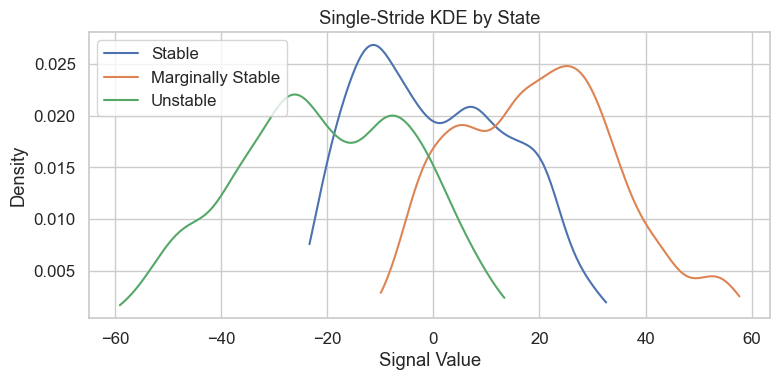

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


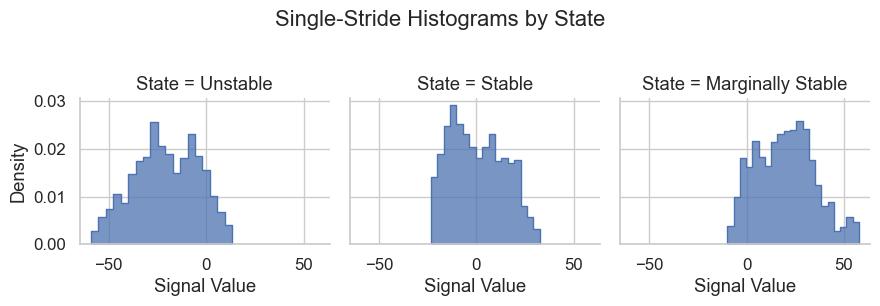

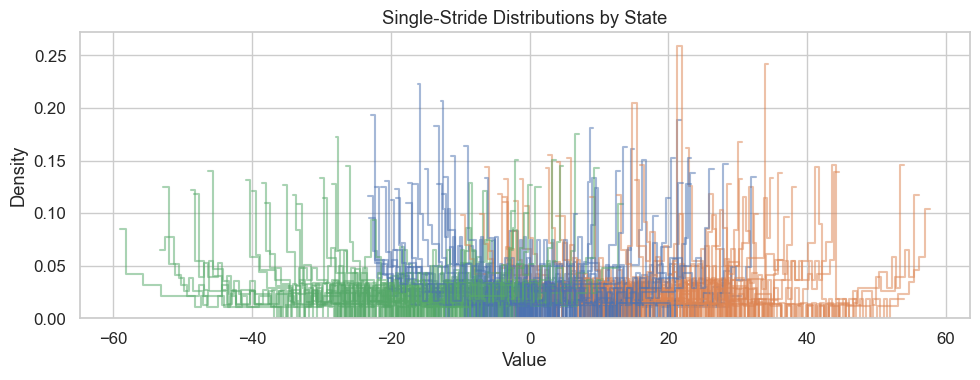

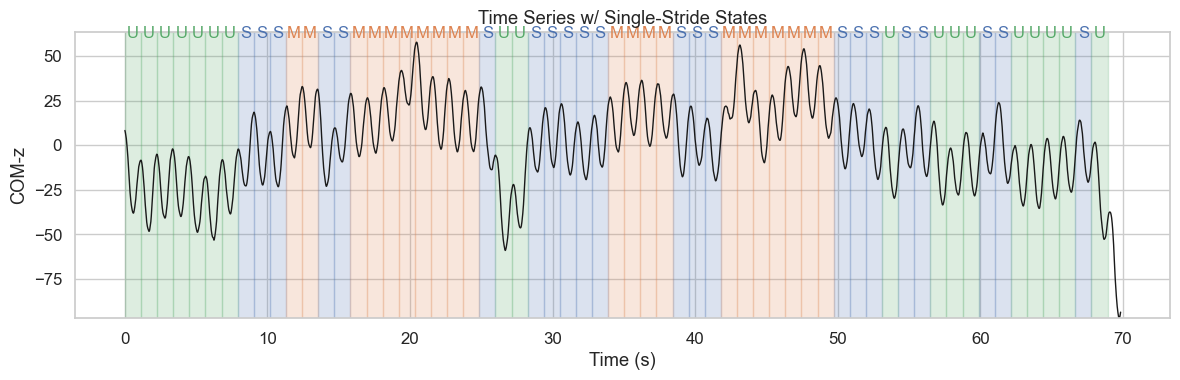

T:
 [[0.591 0.182 0.227]
 [0.19  0.81  0.   ]
 [0.294 0.    0.706]]
Π:
 [0.367 0.35  0.283]
τ:
 [2.444 5.25  3.4  ]
Frac: {'patient_id': '09_PWS', 'frac_state_0': np.float64(0.36065573770491804), 'frac_state_1': np.float64(0.3442622950819672), 'frac_state_2': np.float64(0.29508196721311475)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_36824\1102886088.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


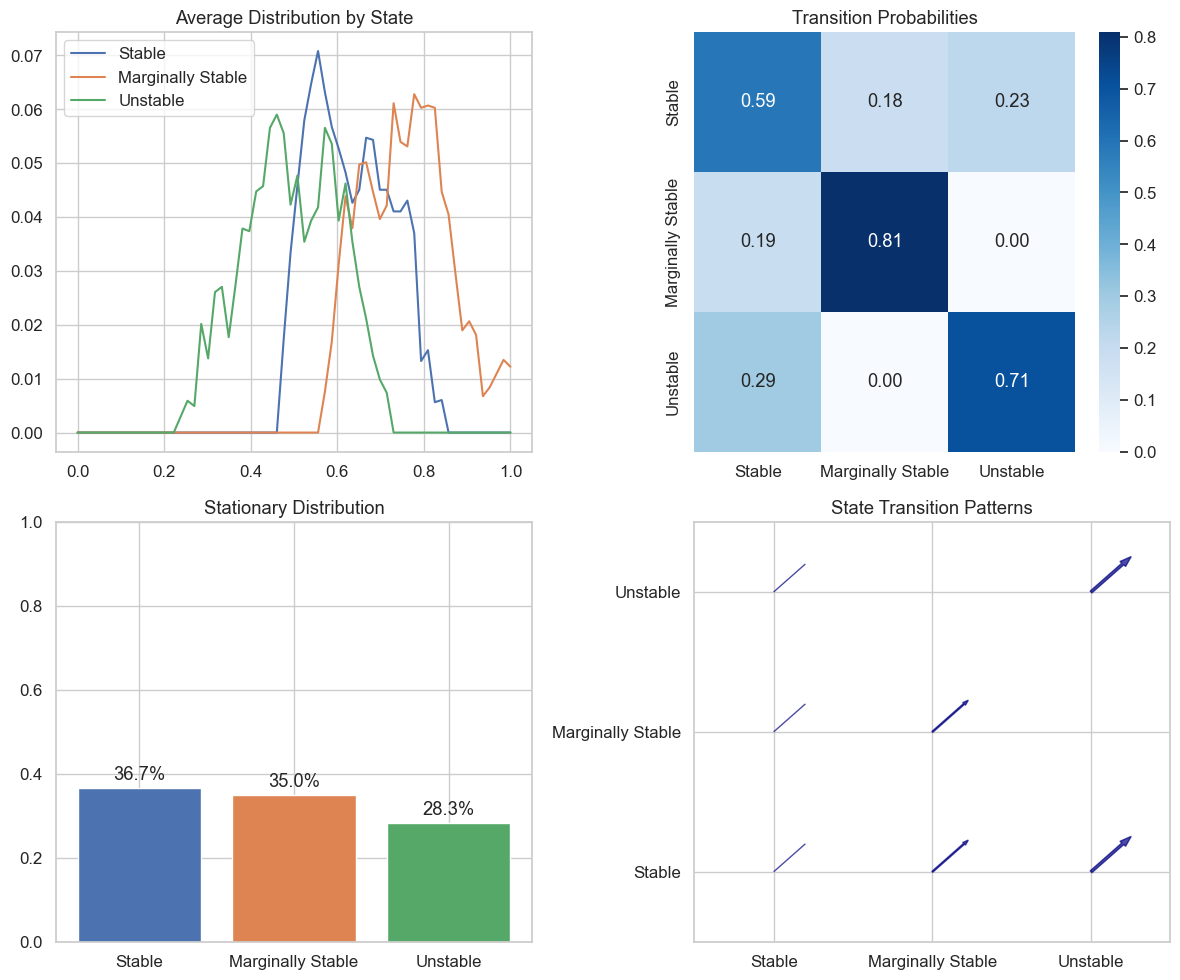

In [10]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("09_PWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

Single-stride window = 113 samples (~1.13s)


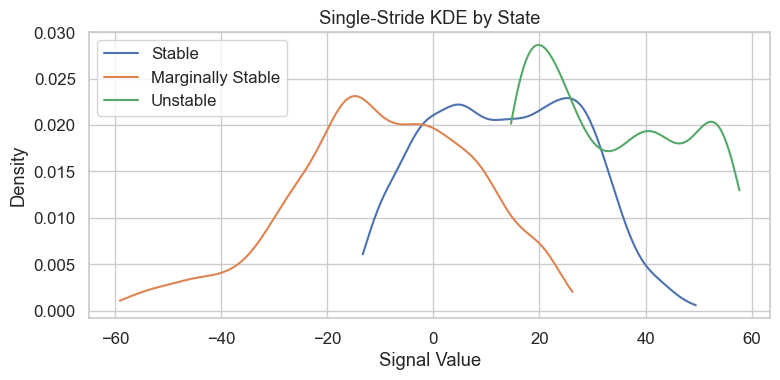

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


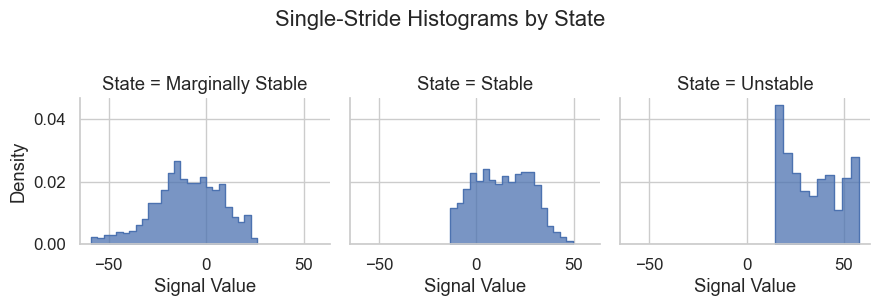

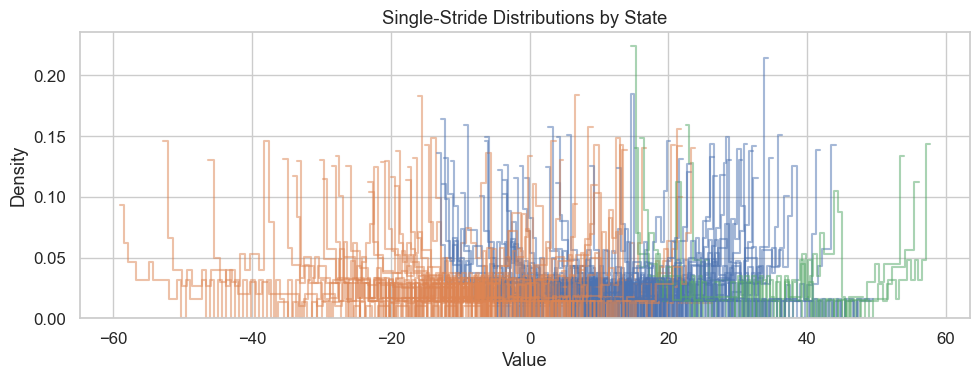

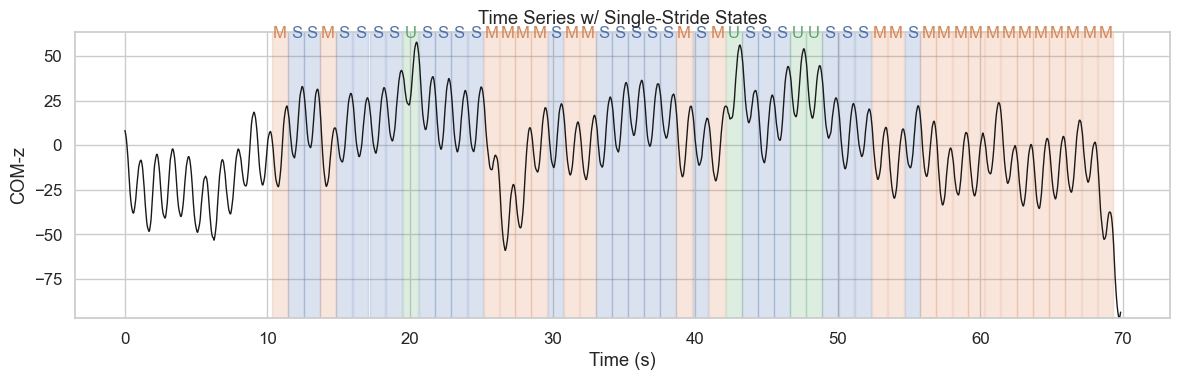

T:
 [[0.625 0.292 0.083]
 [0.261 0.696 0.043]
 [0.75  0.    0.25 ]]
Π:
 [0.471 0.451 0.078]
τ:
 [2.667 3.286 1.333]
Frac: {'patient_id': '04_PWS', 'frac_state_0': np.float64(0.46153846153846156), 'frac_state_1': np.float64(0.46153846153846156), 'frac_state_2': np.float64(0.07692307692307693)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_36824\252307157.py:150: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'], row['to'], row[0]


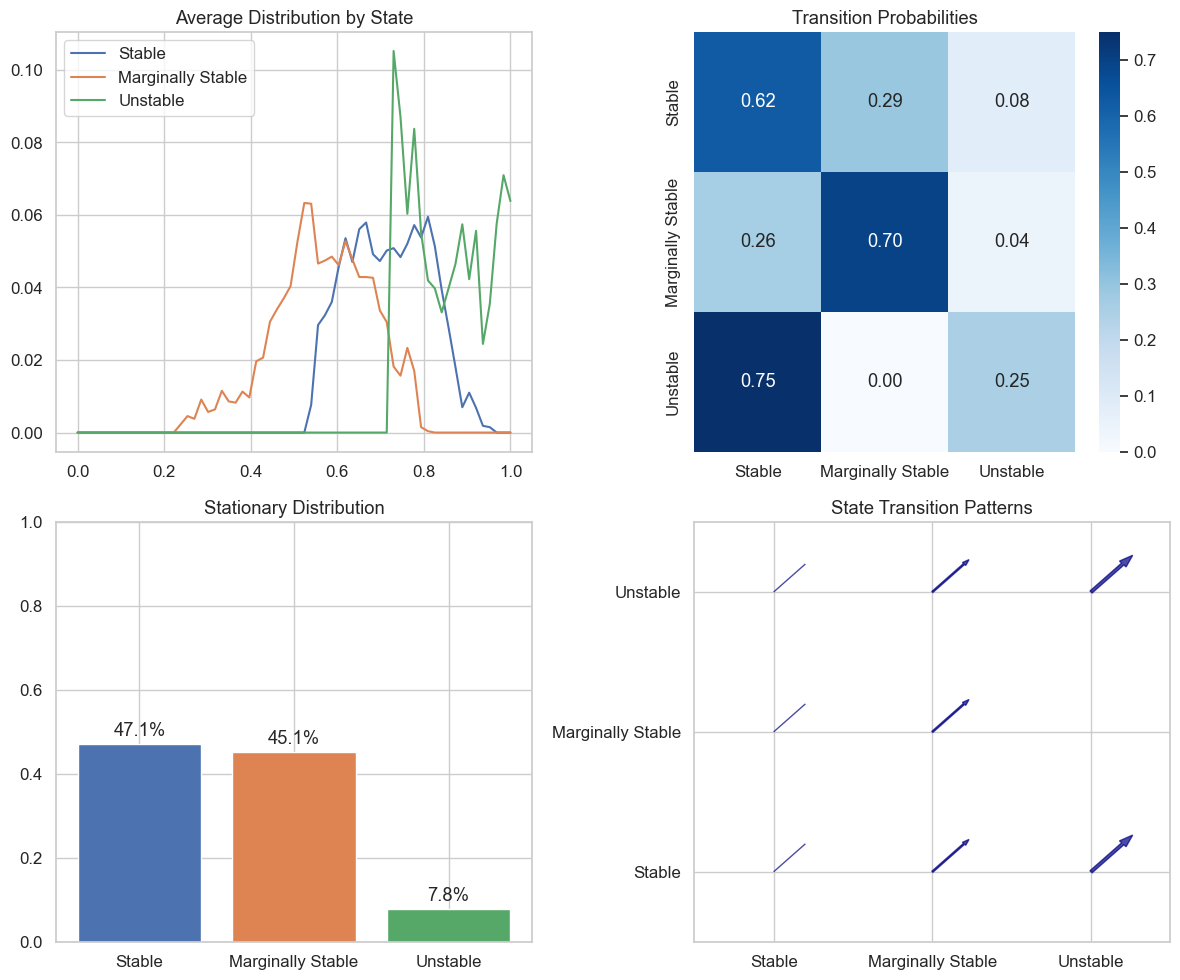

In [18]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM_Strides("04_PWS", n_states=3,
                        #   window_size=win_samps,
                        #   window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_stride_metrics(ts,strikes, fs)
    states= msm.identify_stability_states()
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]

            for _, row in df.iloc[idxs].iterrows()
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start: start+int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = row.duration
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### SWS

Single-stride window = 145 samples (~1.45s)


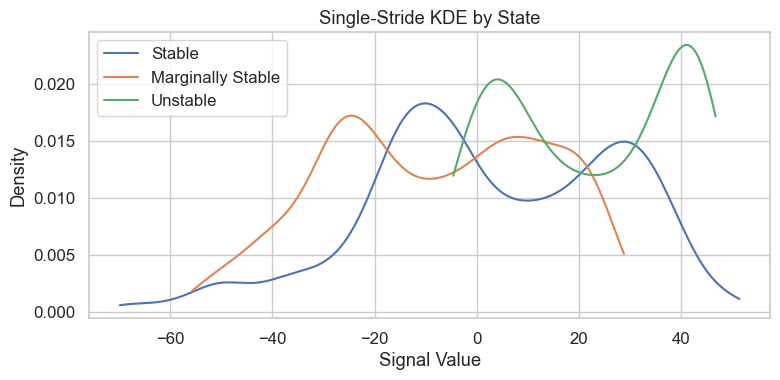

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


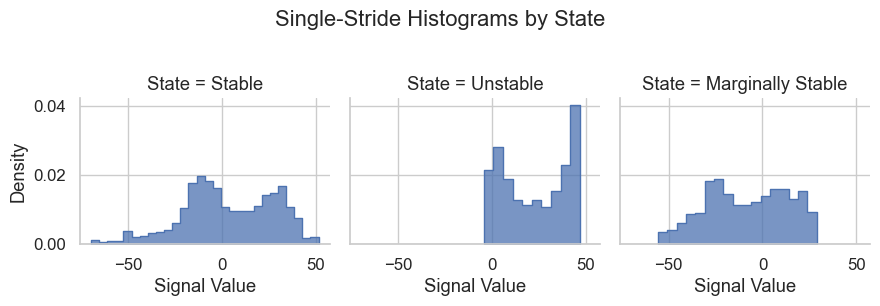

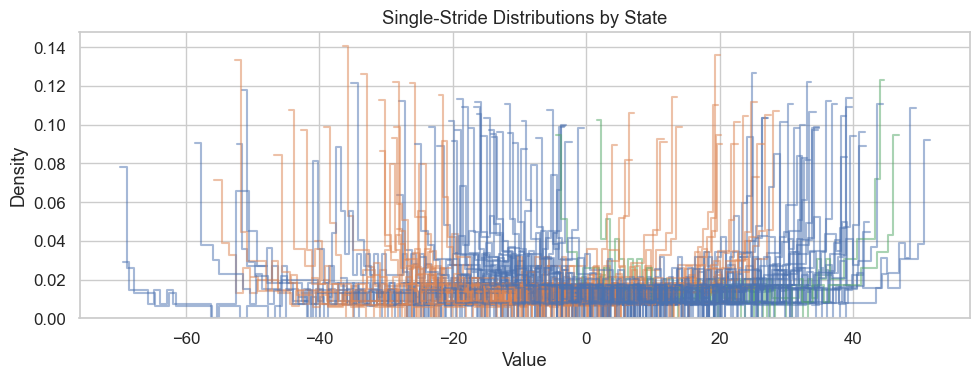

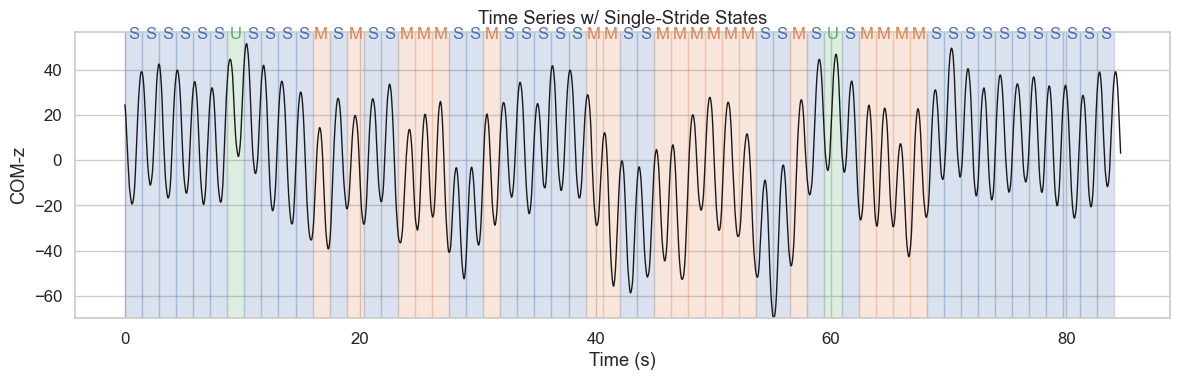

T:
 [[0.722 0.222 0.056]
 [0.421 0.579 0.   ]
 [1.    0.    0.   ]]
Π:
 [0.632 0.333 0.035]
τ:
 [3.6   2.375 1.   ]
Frac: {'patient_id': '04_SWS', 'frac_state_0': np.float64(0.6379310344827587), 'frac_state_1': np.float64(0.3275862068965517), 'frac_state_2': np.float64(0.034482758620689655)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


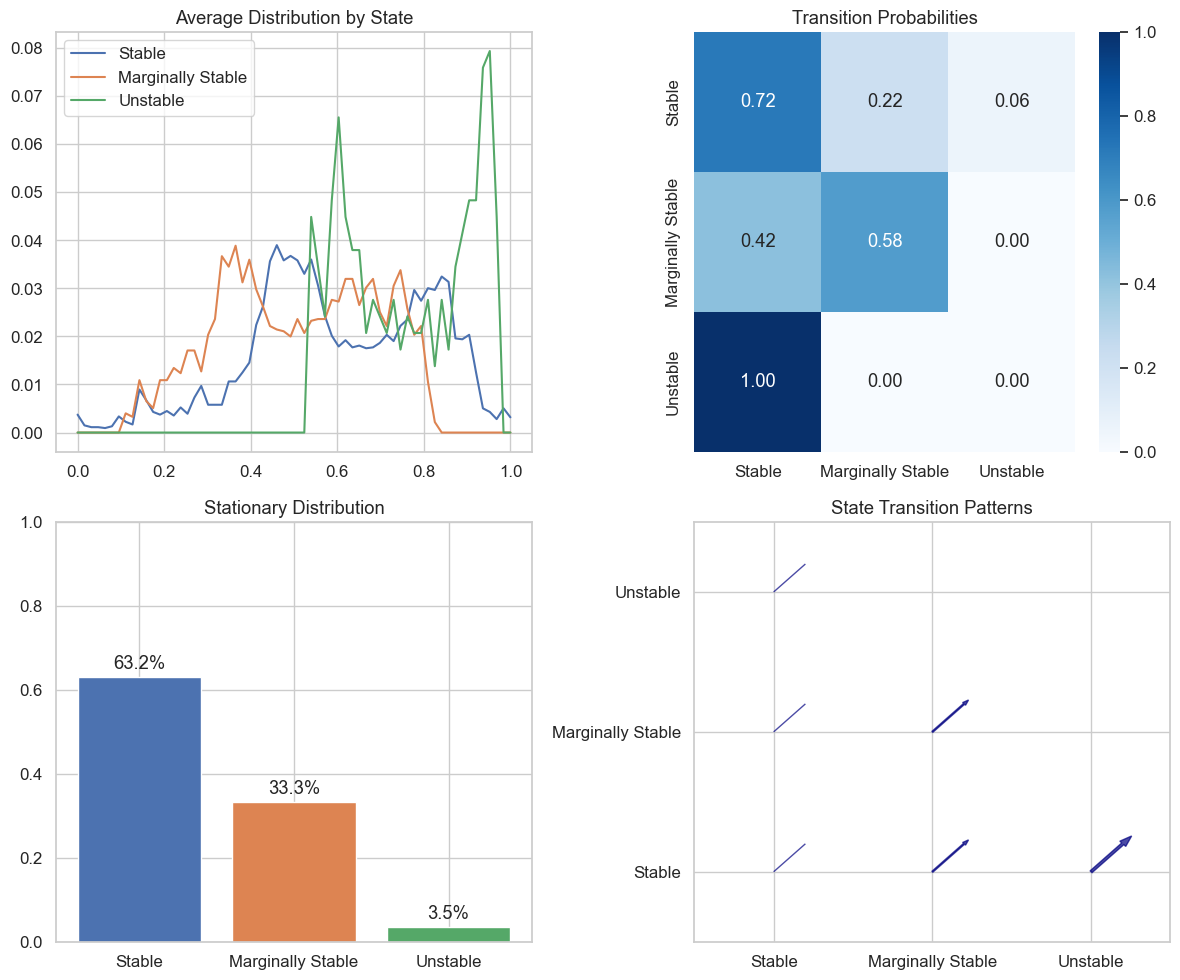

In [18]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "SWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "04" / "SWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("04_SWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### FWS

Single-stride window = 99 samples (~0.99s)


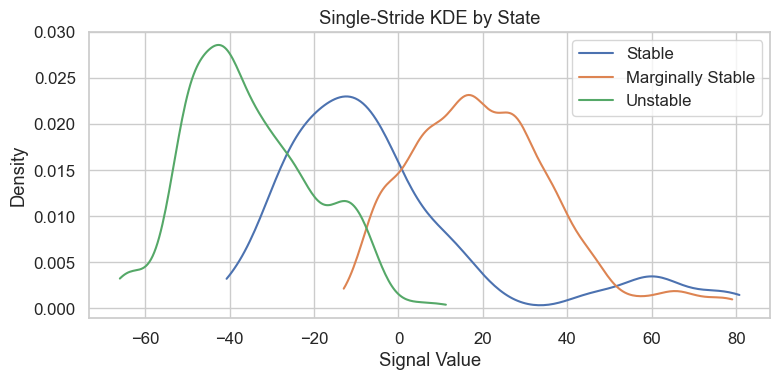

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


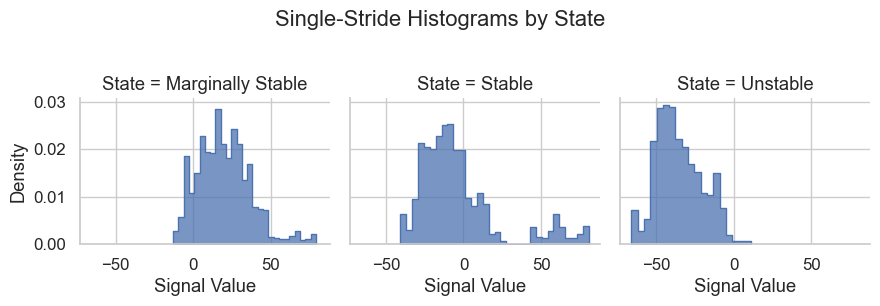

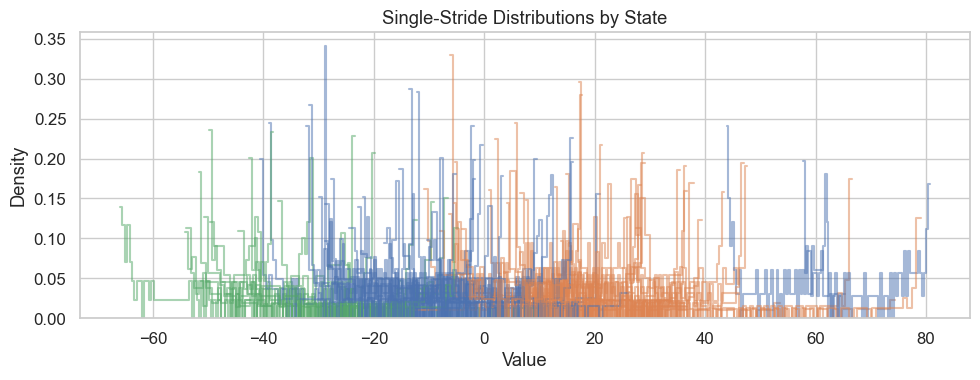

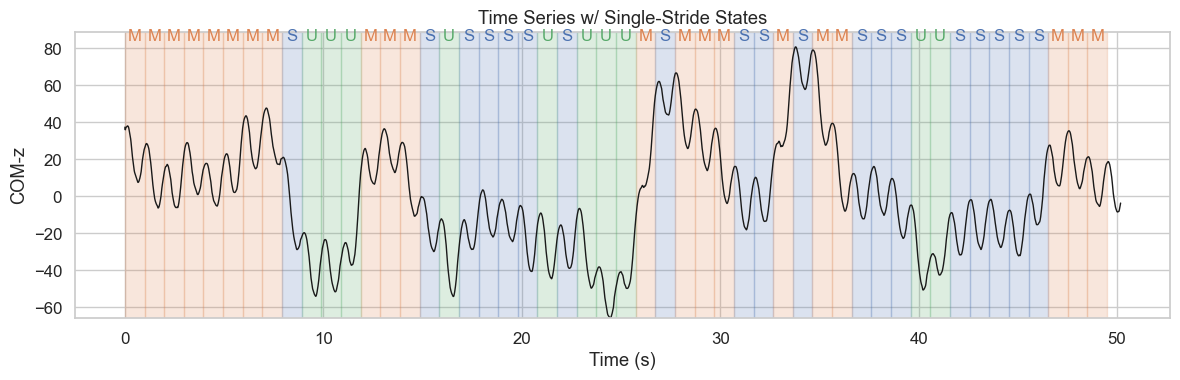

T:
 [[0.526 0.211 0.263]
 [0.3   0.7   0.   ]
 [0.3   0.2   0.5  ]]
Π:
 [0.388 0.408 0.204]
τ:
 [2.111 3.333 2.   ]
Frac: {'patient_id': '04_FWS', 'frac_state_0': np.float64(0.38), 'frac_state_1': np.float64(0.42), 'frac_state_2': np.float64(0.2)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


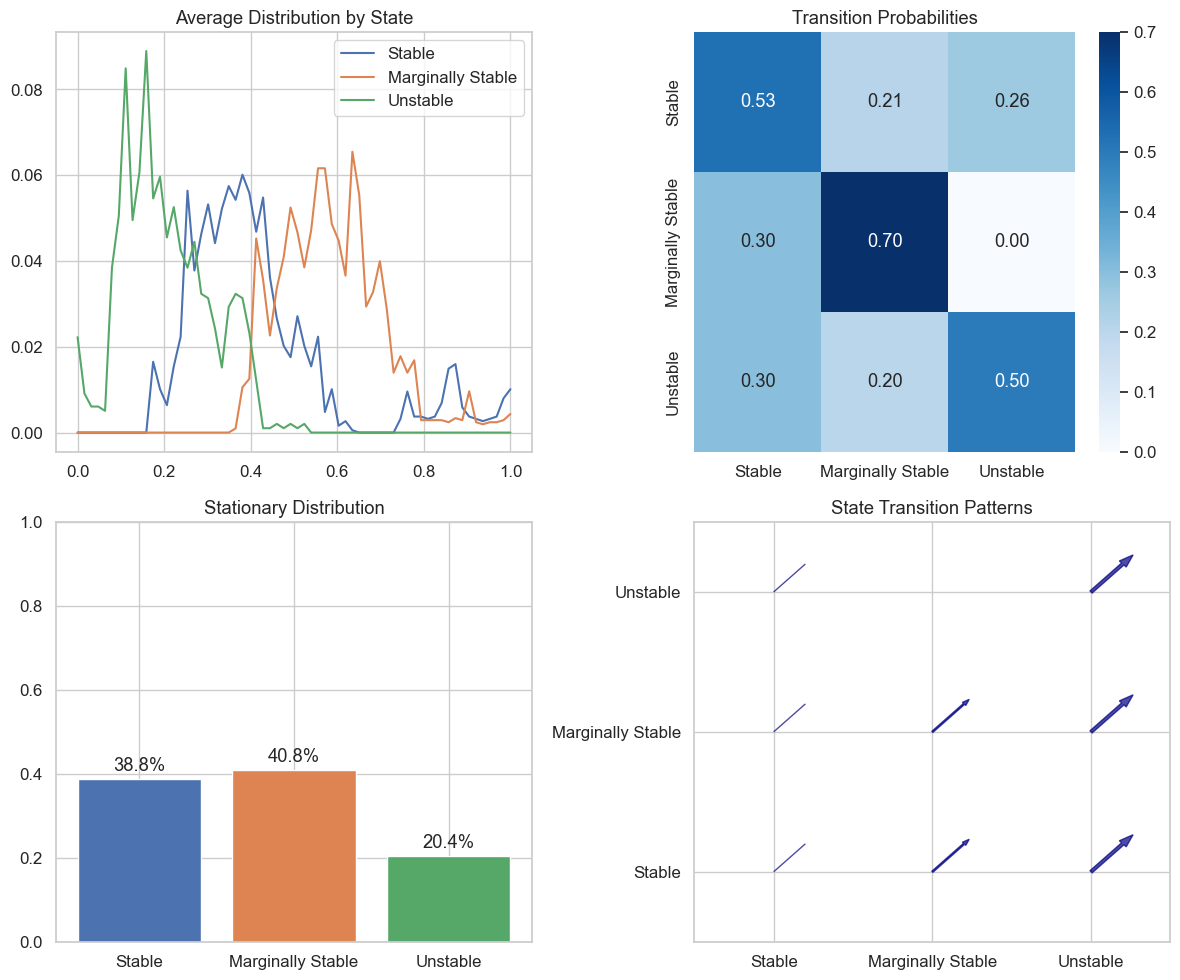

In [17]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "FWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "04" / "FWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("04_FWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

## Patient 09 - Stroke

### PWS

Single-stride window = 122 samples (~1.22s)


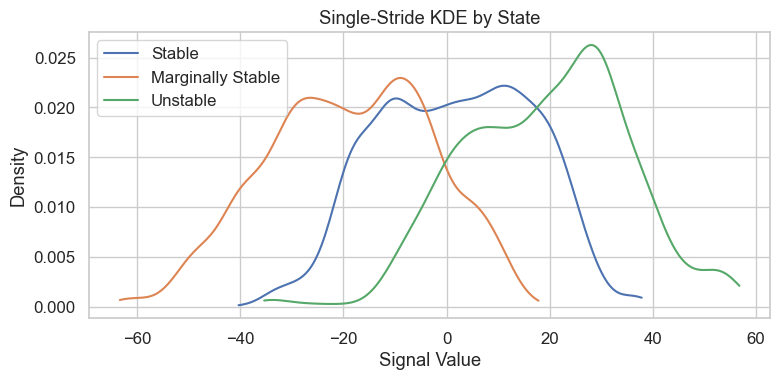

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


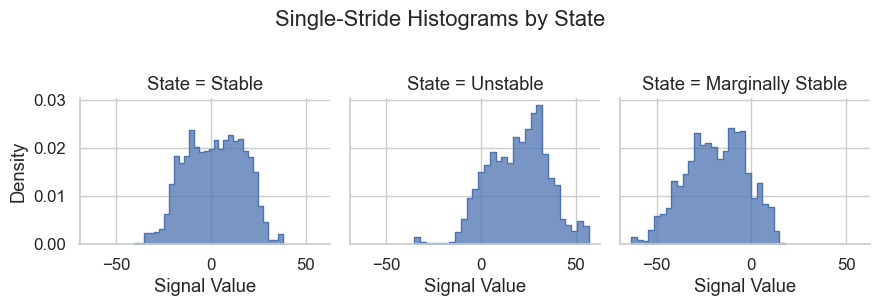

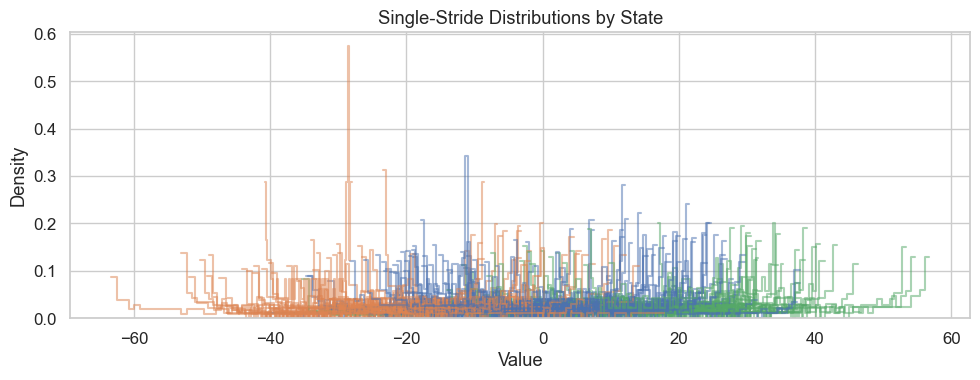

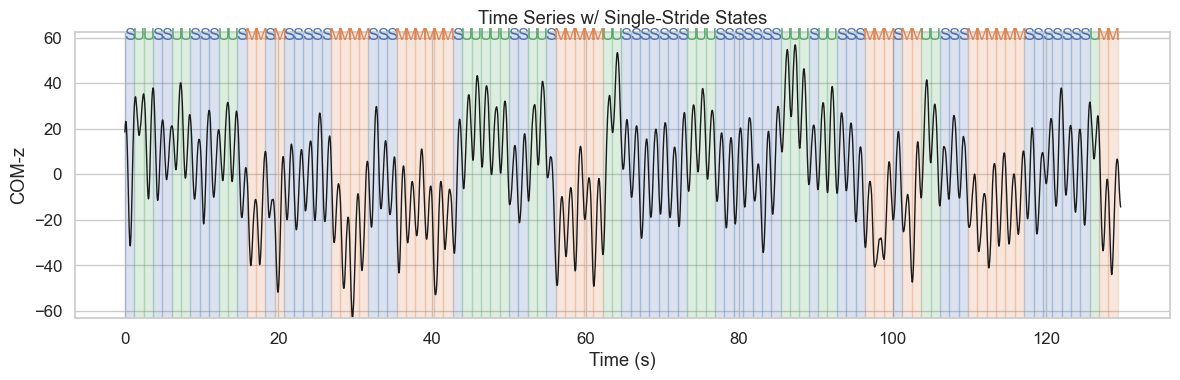

T:
 [[0.653 0.163 0.184]
 [0.2   0.733 0.067]
 [0.385 0.038 0.577]]
Π:
 [0.448 0.309 0.243]
τ:
 [2.882 3.75  2.364]
Frac: {'patient_id': '09_PWS', 'frac_state_0': np.float64(0.46226415094339623), 'frac_state_1': np.float64(0.29245283018867924), 'frac_state_2': np.float64(0.24528301886792453)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


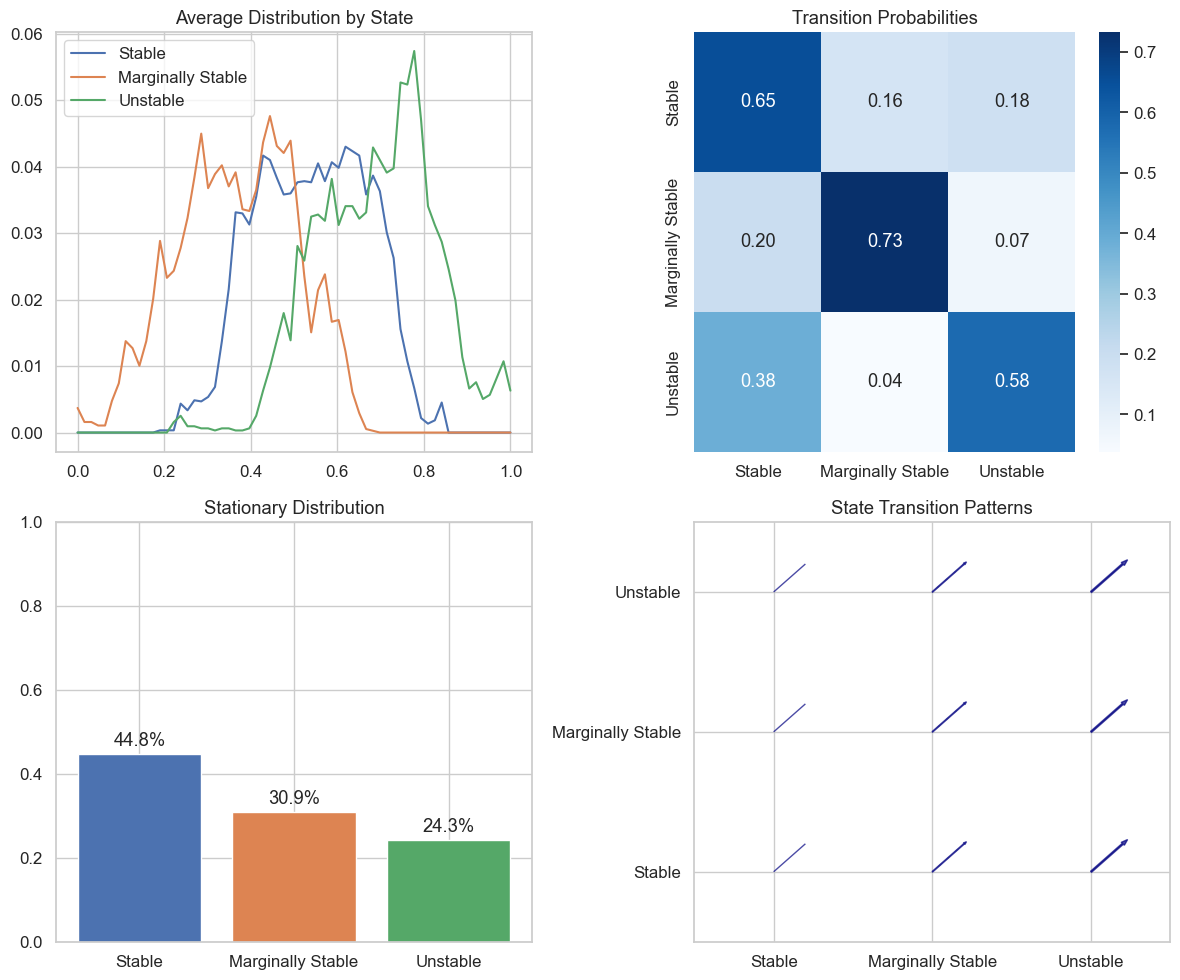

In [20]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "09" / "PWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "09" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("09_PWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### FWS

Single-stride window = 101 samples (~1.01s)


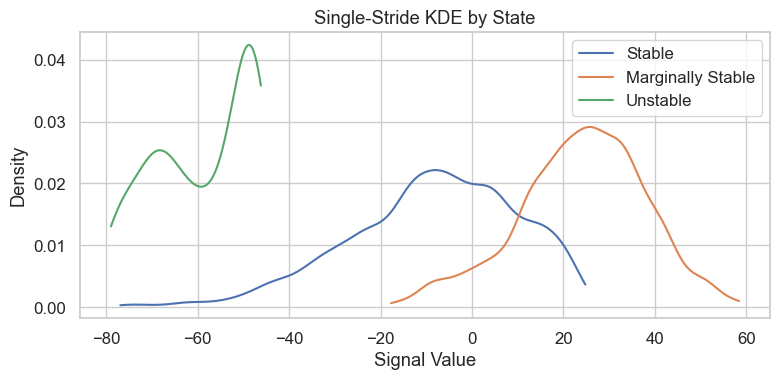

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


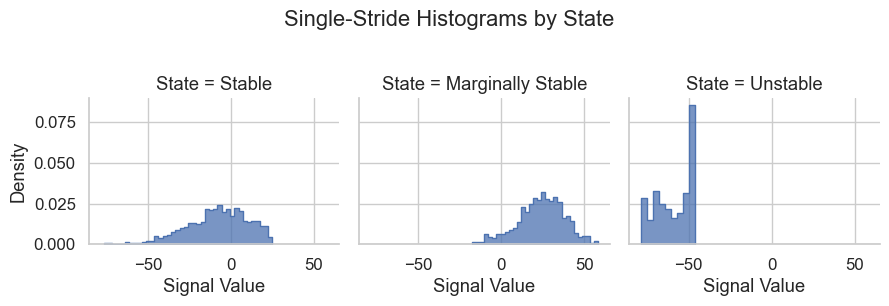

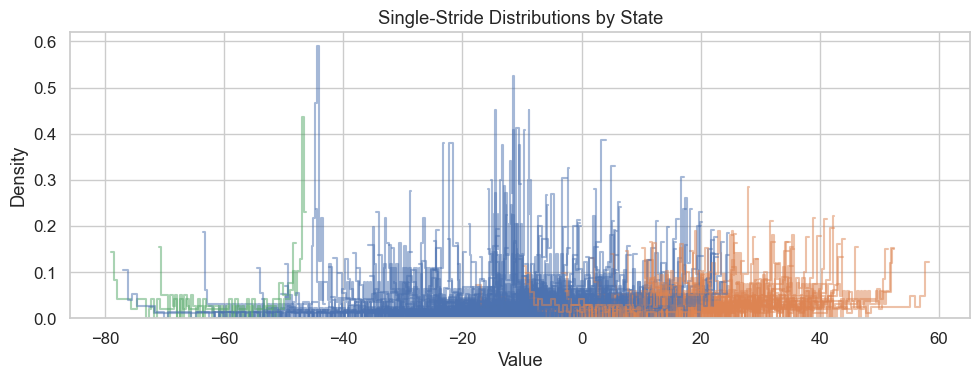

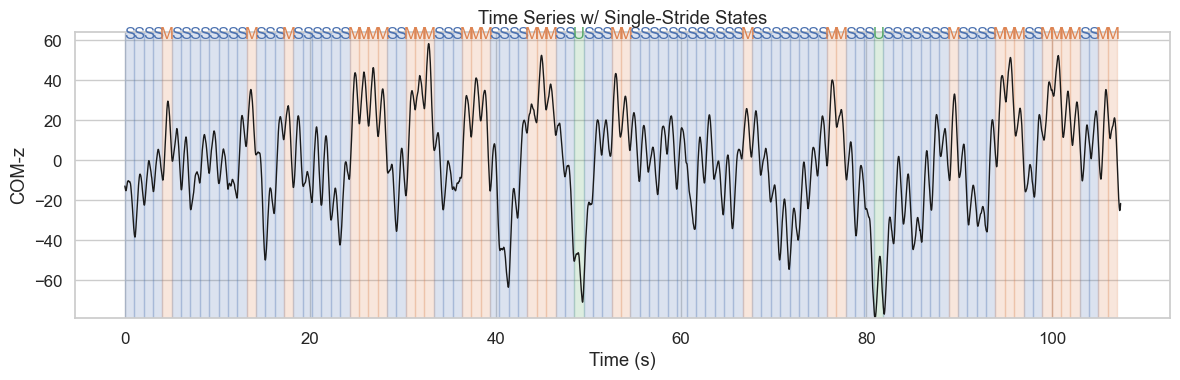

T:
 [[0.781 0.192 0.027]
 [0.433 0.567 0.   ]
 [1.    0.    0.   ]]
Π:
 [0.68  0.301 0.019]
τ:
 [4.562 2.308 1.   ]
Frac: {'patient_id': '09_FWS', 'frac_state_0': np.float64(0.6886792452830188), 'frac_state_1': np.float64(0.29245283018867924), 'frac_state_2': np.float64(0.018867924528301886)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


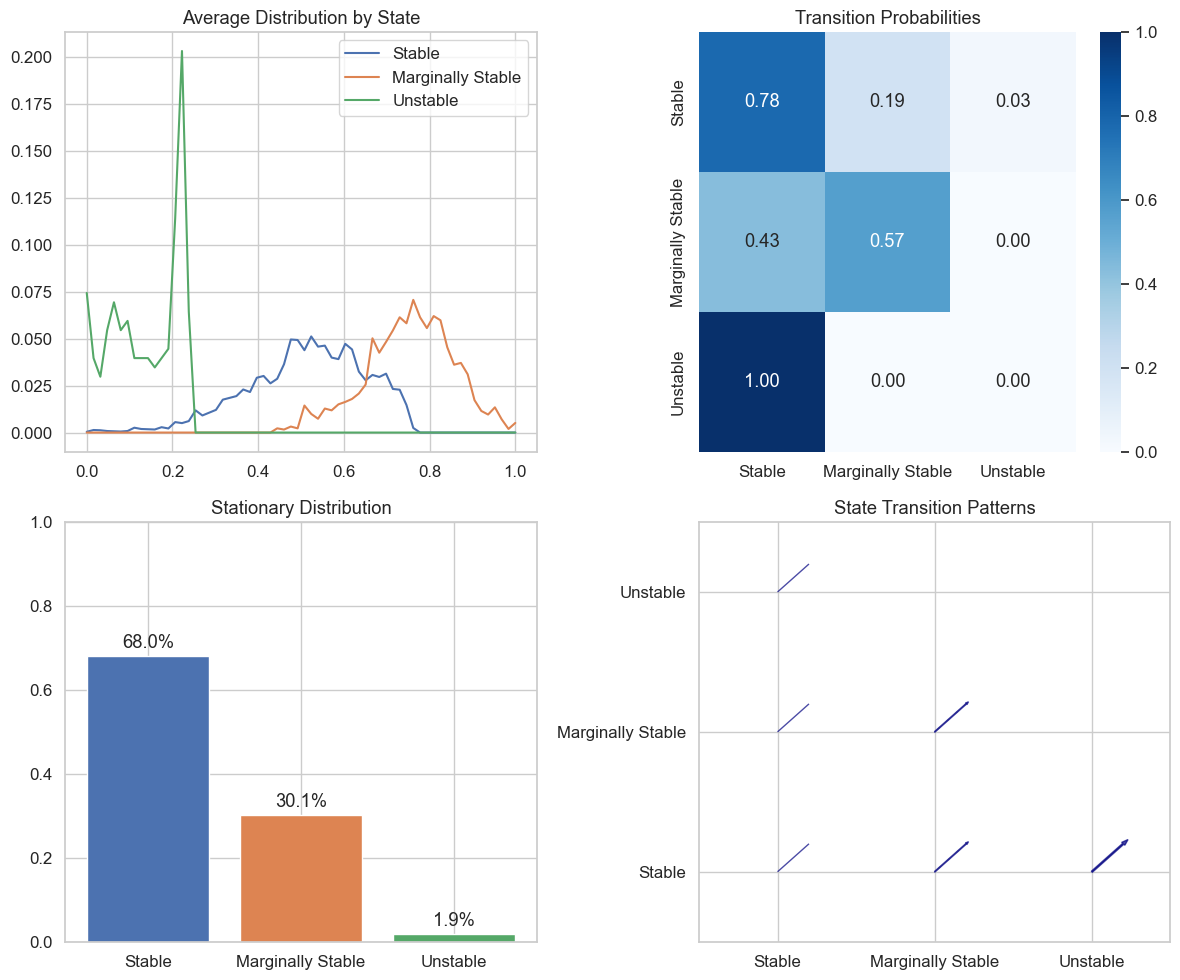

In [21]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "09" / "FWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "09" / "FWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("09_FWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

## Patient 16 - PD + MS 

### PWS

Single-stride window = 109 samples (~1.09s)


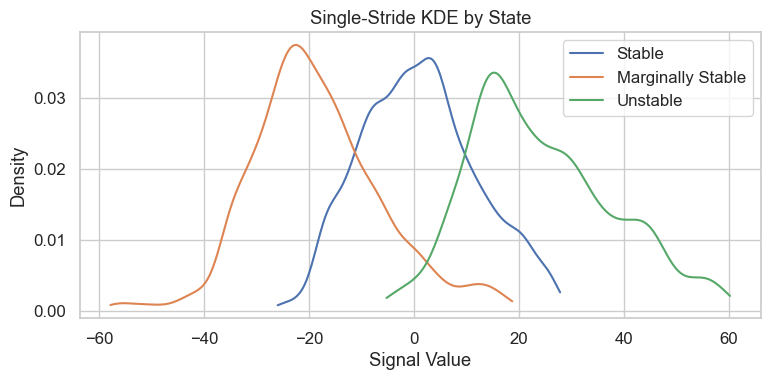

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


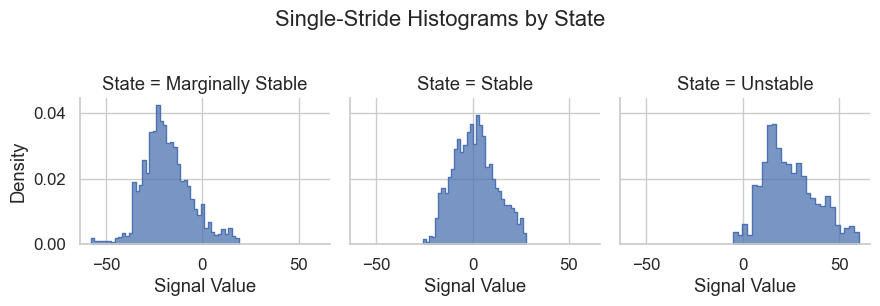

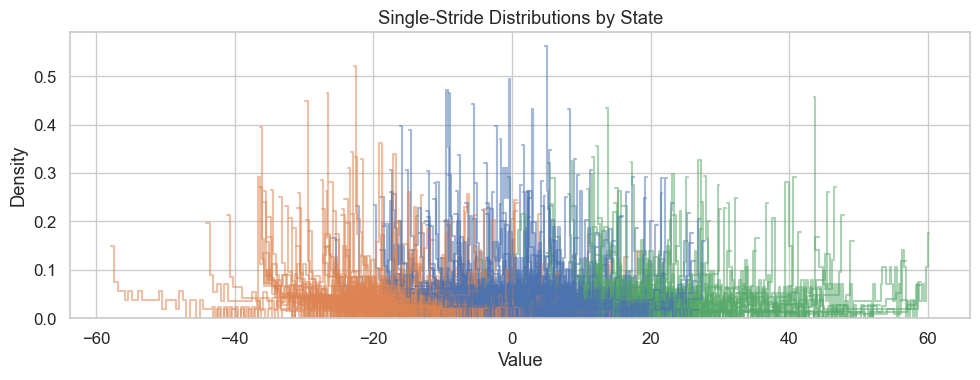

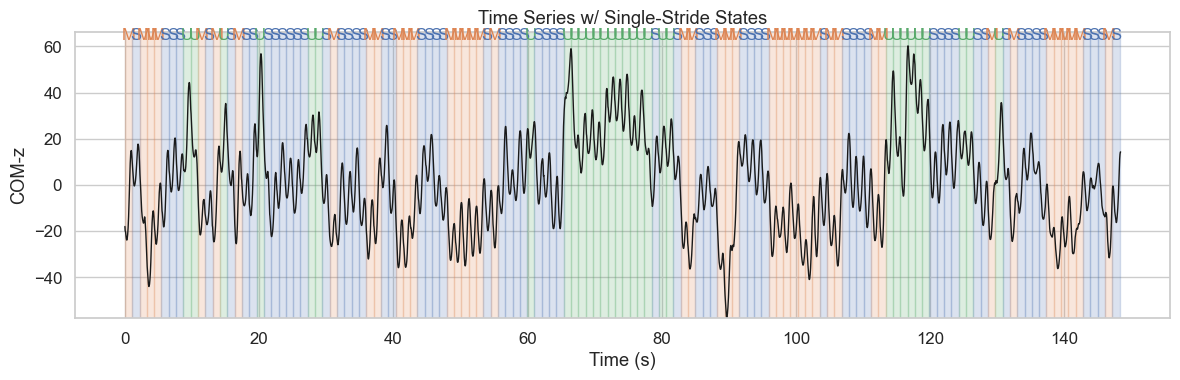

T:
 [[0.613 0.274 0.113]
 [0.372 0.558 0.07 ]
 [0.3   0.033 0.667]]
Π:
 [0.469 0.308 0.223]
τ:
 [2.583 2.263 3.   ]
Frac: {'patient_id': '16_PWS', 'frac_state_0': np.float64(0.4632352941176471), 'frac_state_1': np.float64(0.3161764705882353), 'frac_state_2': np.float64(0.22058823529411764)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


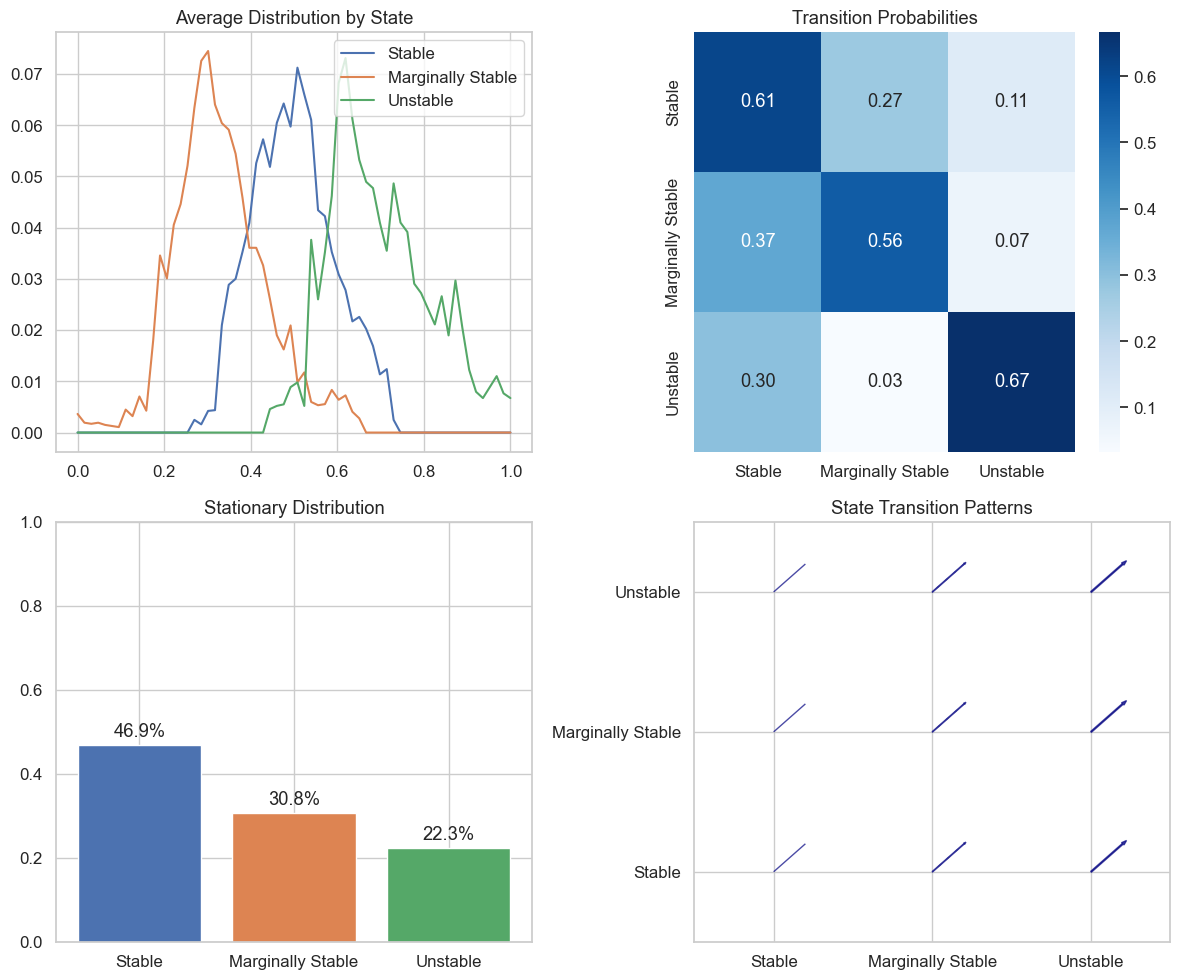

In [22]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("16_PWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### SWS

Single-stride window = 126 samples (~1.26s)


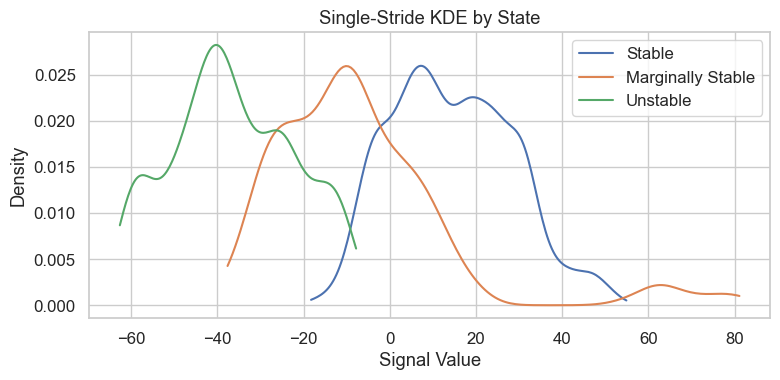

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


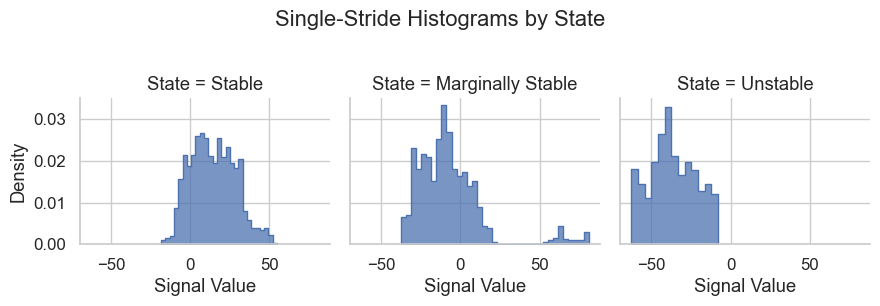

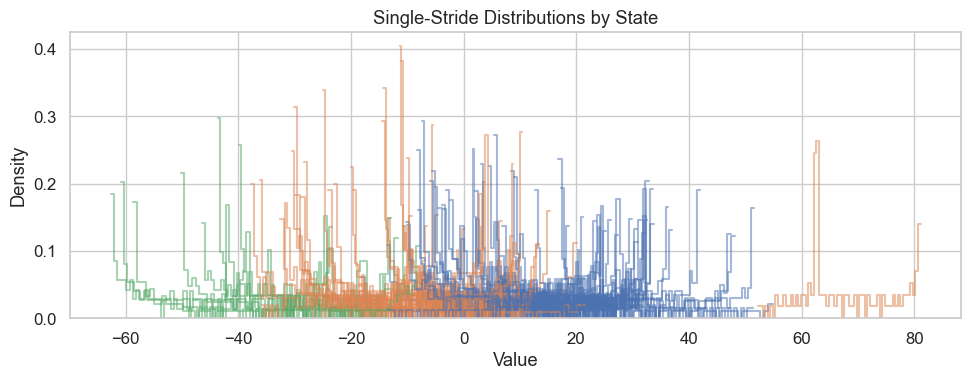

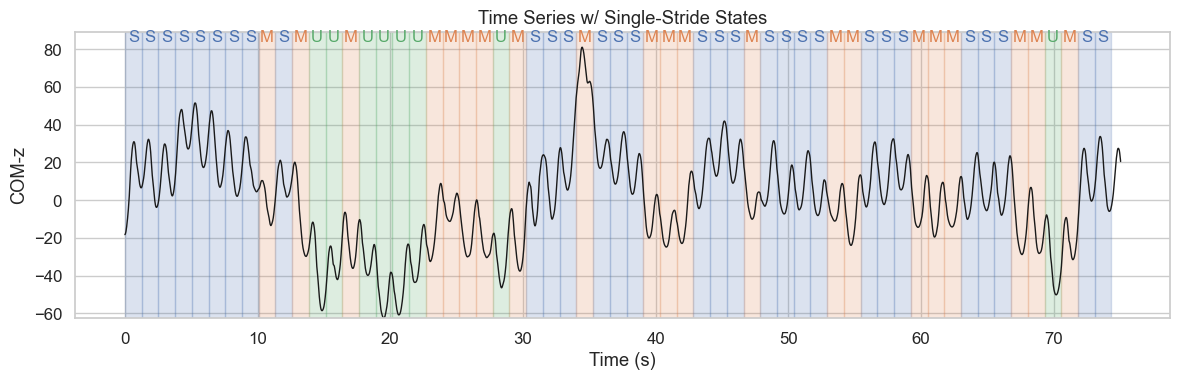

T:
 [[0.724 0.276 0.   ]
 [0.381 0.429 0.19 ]
 [0.    0.5   0.5  ]]
Π:
 [0.5   0.362 0.138]
τ:
 [3.625 1.75  2.   ]
Frac: {'patient_id': '16_SWS', 'frac_state_0': np.float64(0.5084745762711864), 'frac_state_1': np.float64(0.3559322033898305), 'frac_state_2': np.float64(0.13559322033898305)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


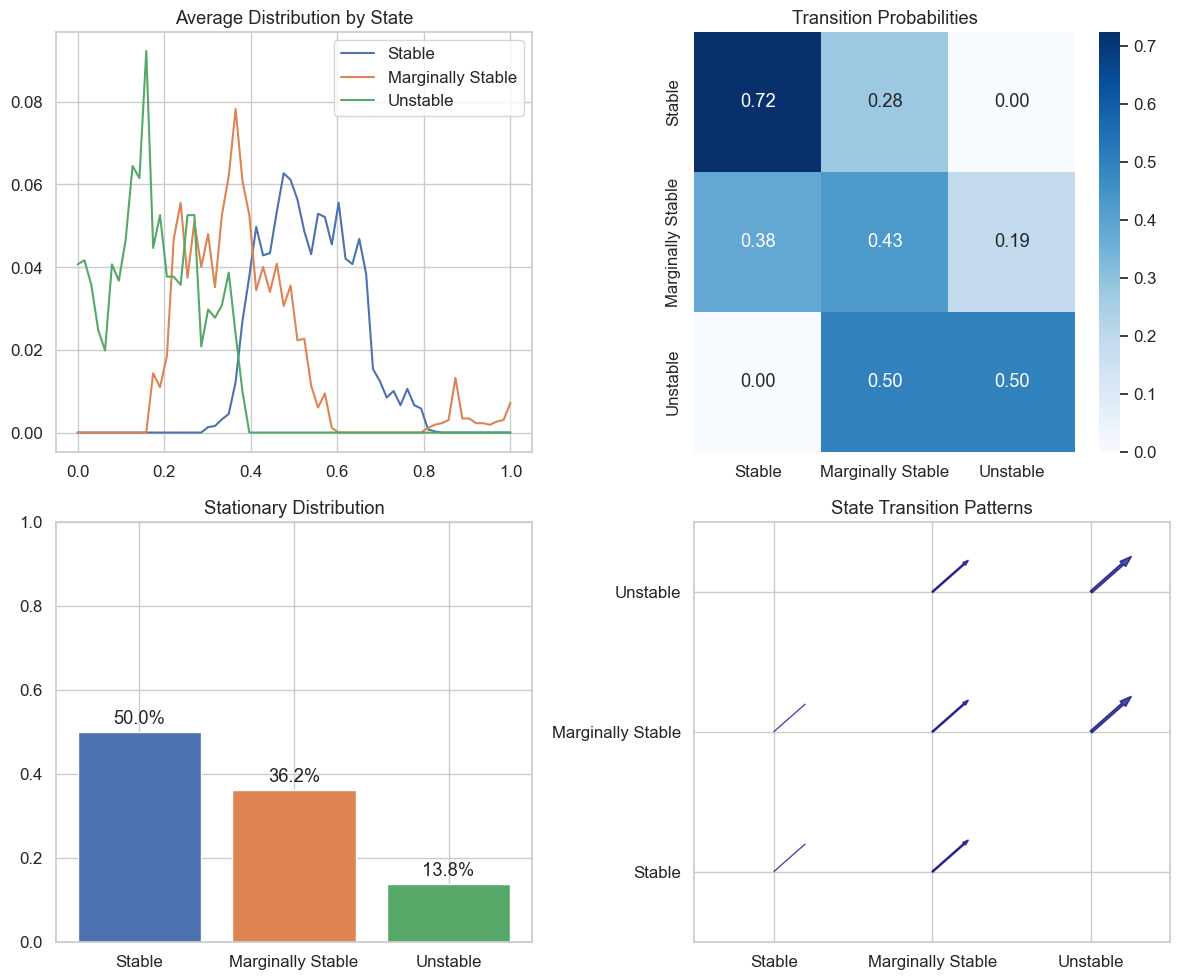

In [23]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "16" / "SWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "16" / "SWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("16_SWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### FWS

Single-stride window = 98 samples (~0.98s)


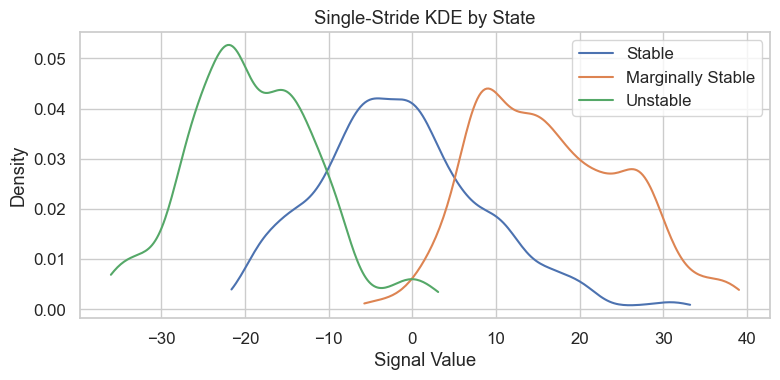

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


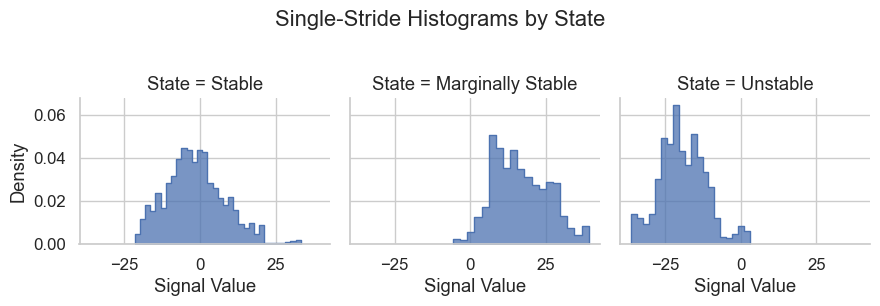

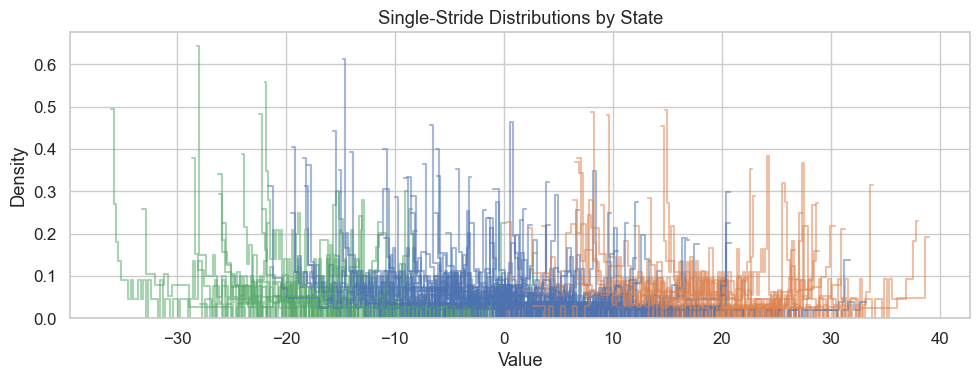

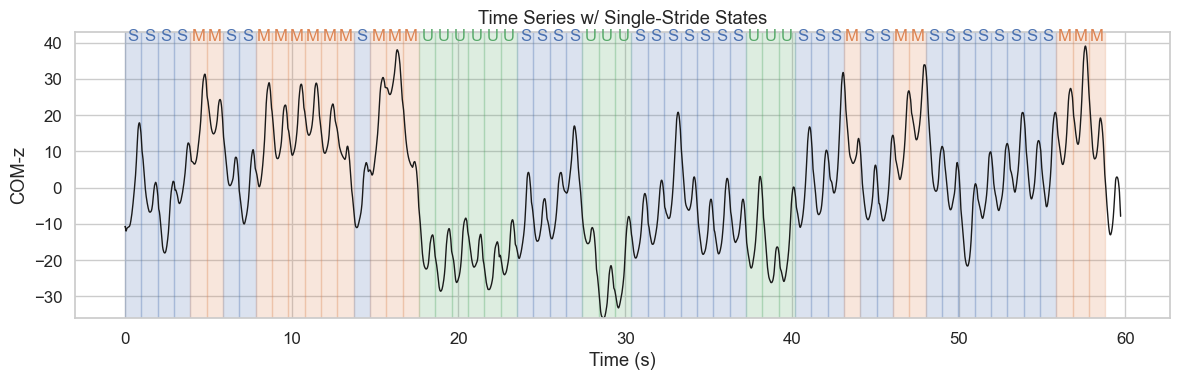

T:
 [[0.742 0.194 0.065]
 [0.25  0.688 0.062]
 [0.25  0.    0.75 ]]
Π:
 [0.492 0.305 0.203]
τ:
 [3.875 3.2   4.   ]
Frac: {'patient_id': '16_FWS', 'frac_state_0': np.float64(0.5166666666666667), 'frac_state_1': np.float64(0.2833333333333333), 'frac_state_2': np.float64(0.2)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


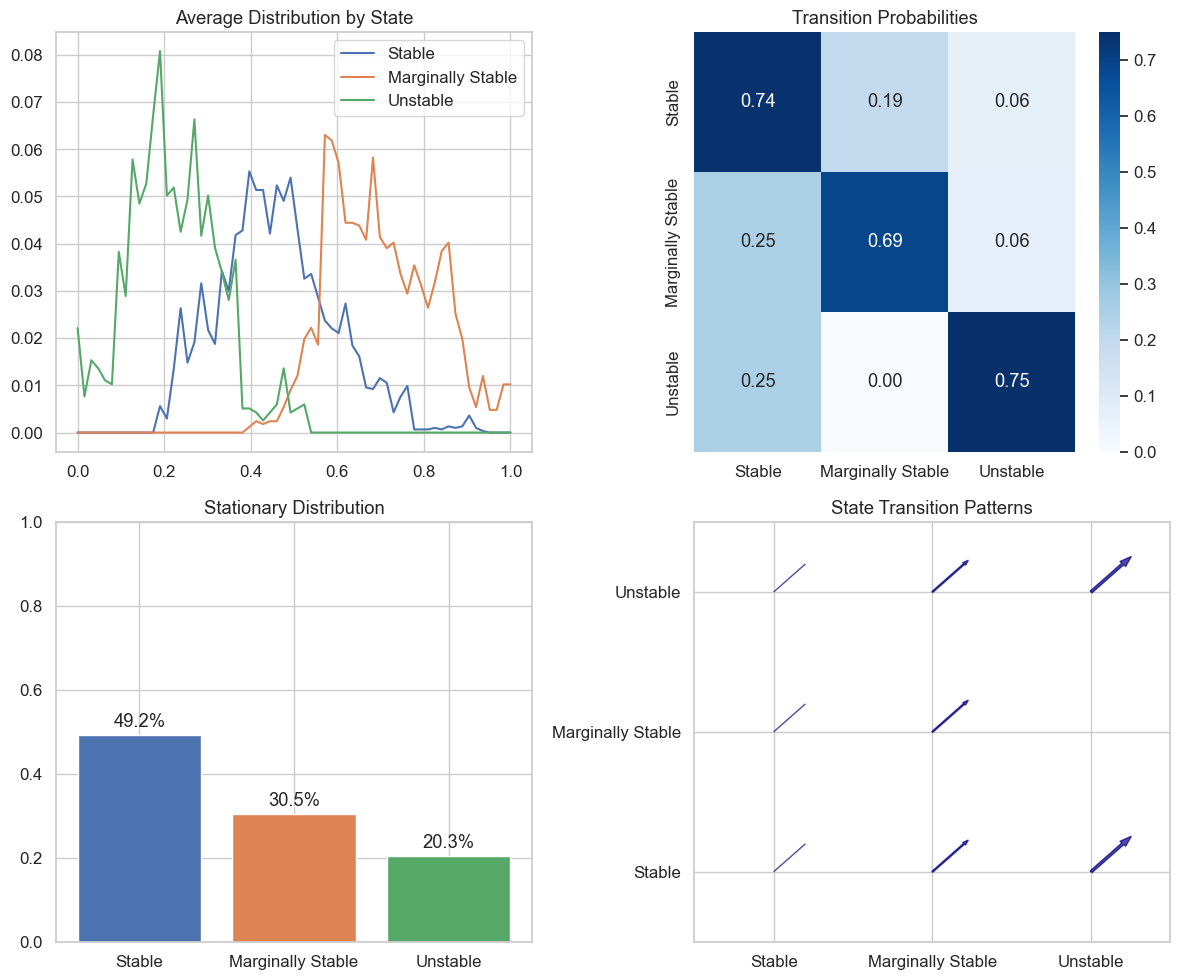

In [24]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "16" / "FWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "16" / "FWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("16_FWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### Patient 18 - Stroke

### PWS

Single-stride window = 117 samples (~1.17s)


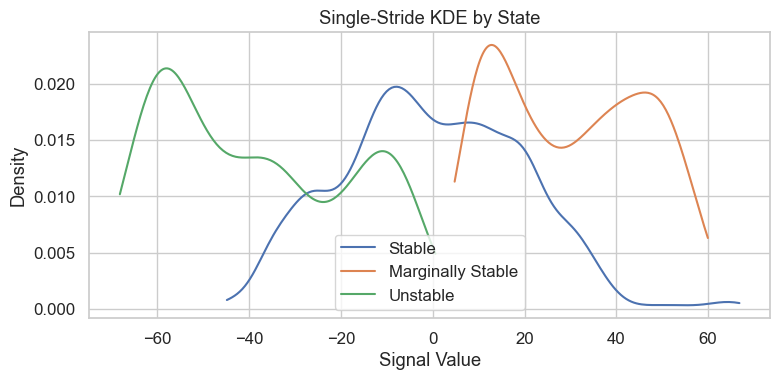

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


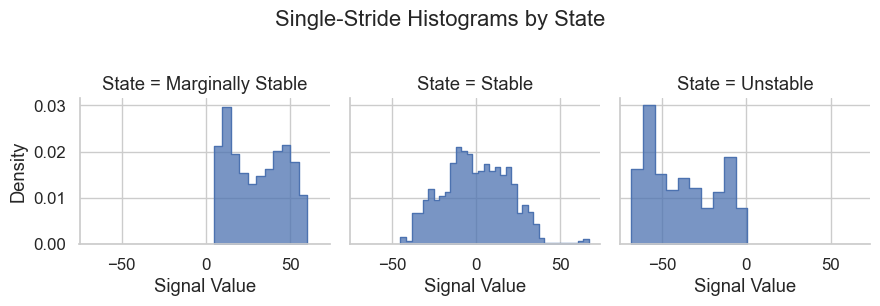

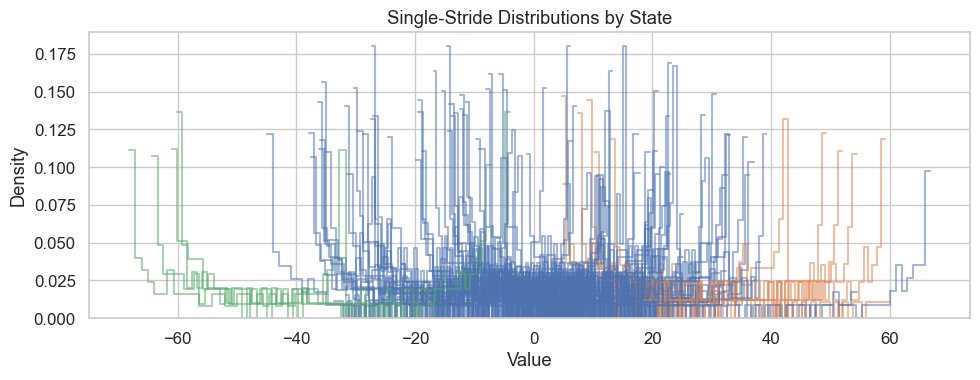

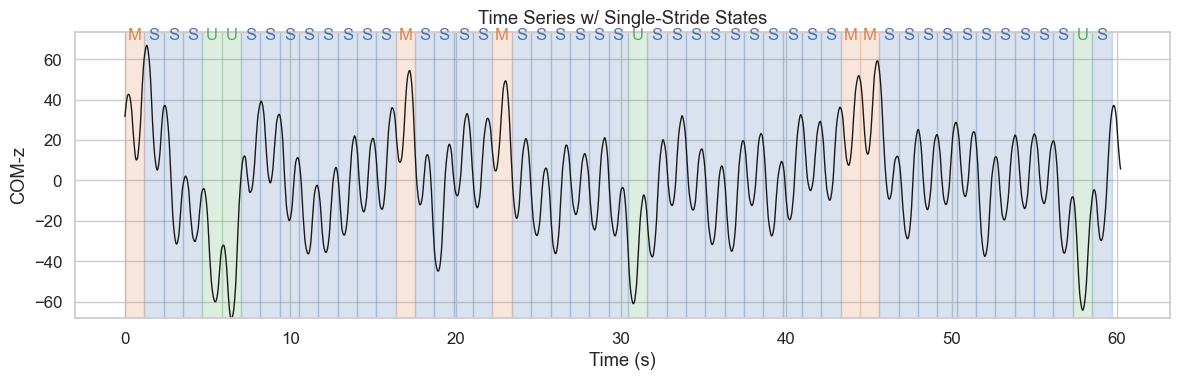

T:
 [[0.854 0.073 0.073]
 [0.8   0.2   0.   ]
 [0.75  0.    0.25 ]]
Π:
 [0.841 0.077 0.082]
τ:
 [6.833 1.25  1.333]
Frac: {'patient_id': '18_PWS', 'frac_state_0': np.float64(0.8235294117647058), 'frac_state_1': np.float64(0.09803921568627451), 'frac_state_2': np.float64(0.0784313725490196)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


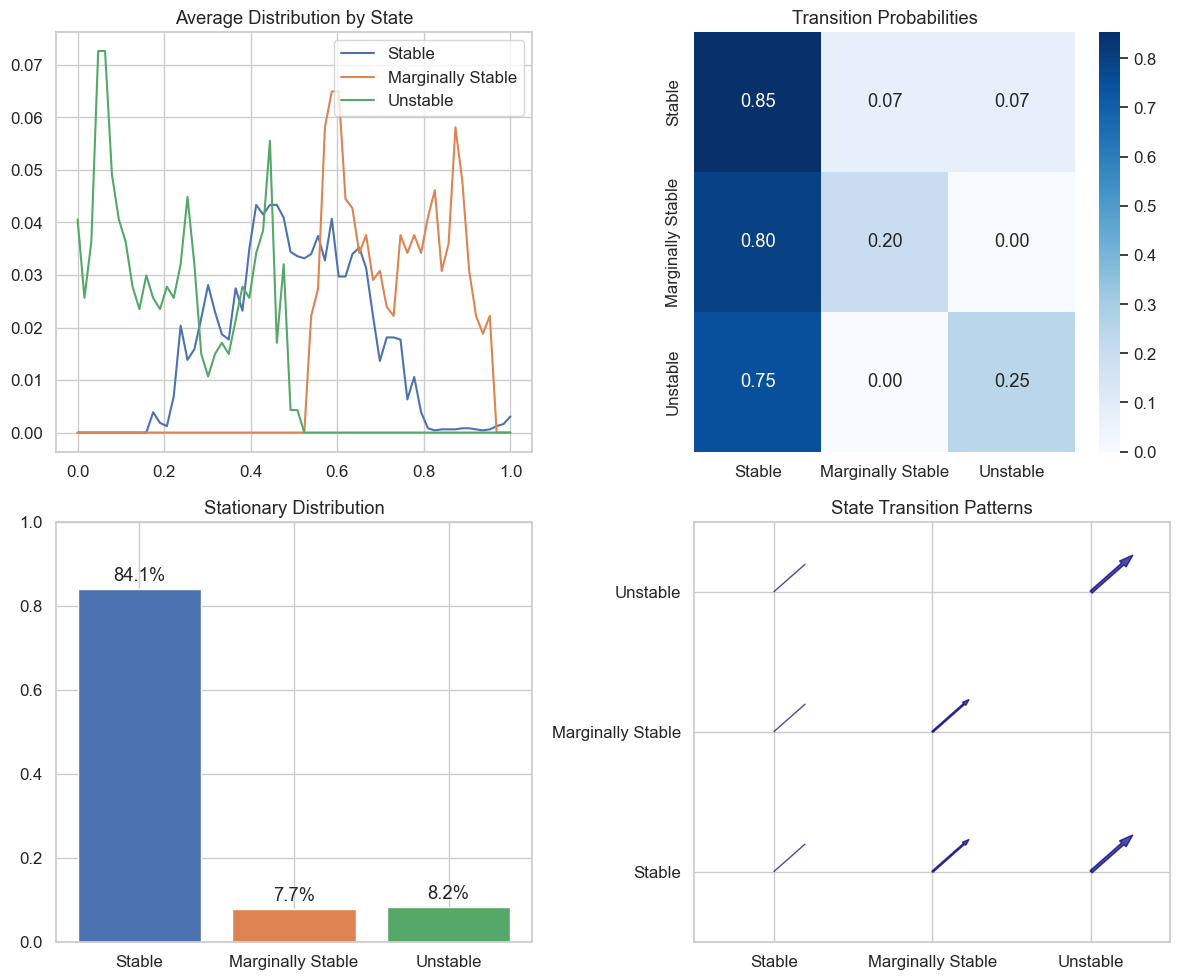

In [32]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "18" / "PWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "18" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("18_PWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### SWS

Single-stride window = 159 samples (~1.59s)


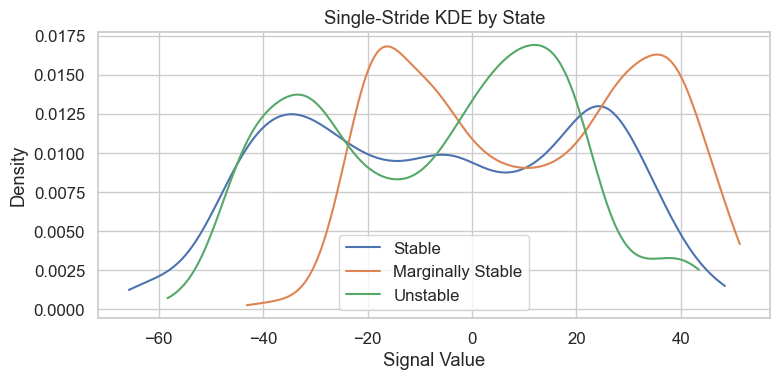

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


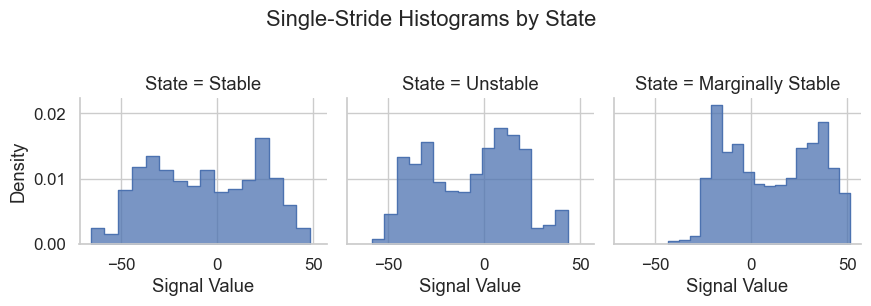

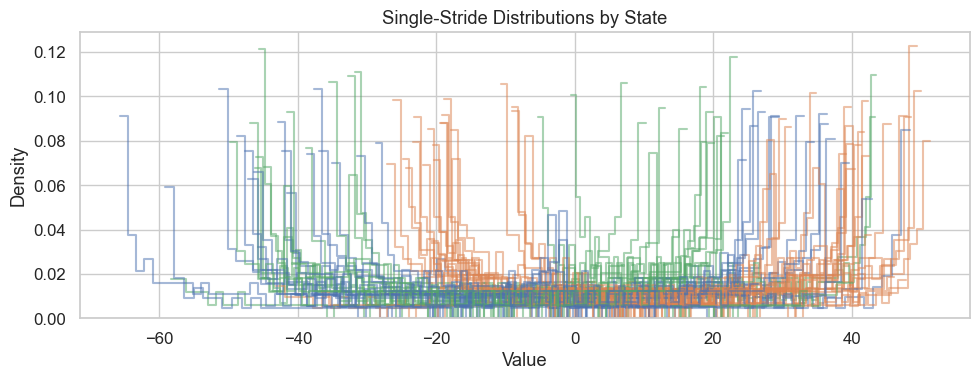

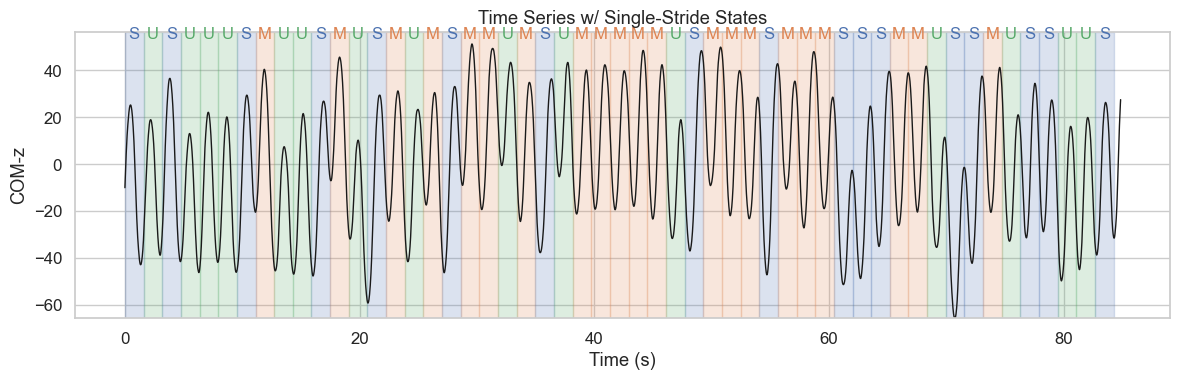

T:
 [[0.25  0.5   0.25 ]
 [0.19  0.476 0.333]
 [0.533 0.2   0.267]]
Π:
 [0.308 0.404 0.288]
τ:
 [1.333 1.909 1.364]
Frac: {'patient_id': '18_SWS', 'frac_state_0': np.float64(0.32075471698113206), 'frac_state_1': np.float64(0.39622641509433965), 'frac_state_2': np.float64(0.2830188679245283)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


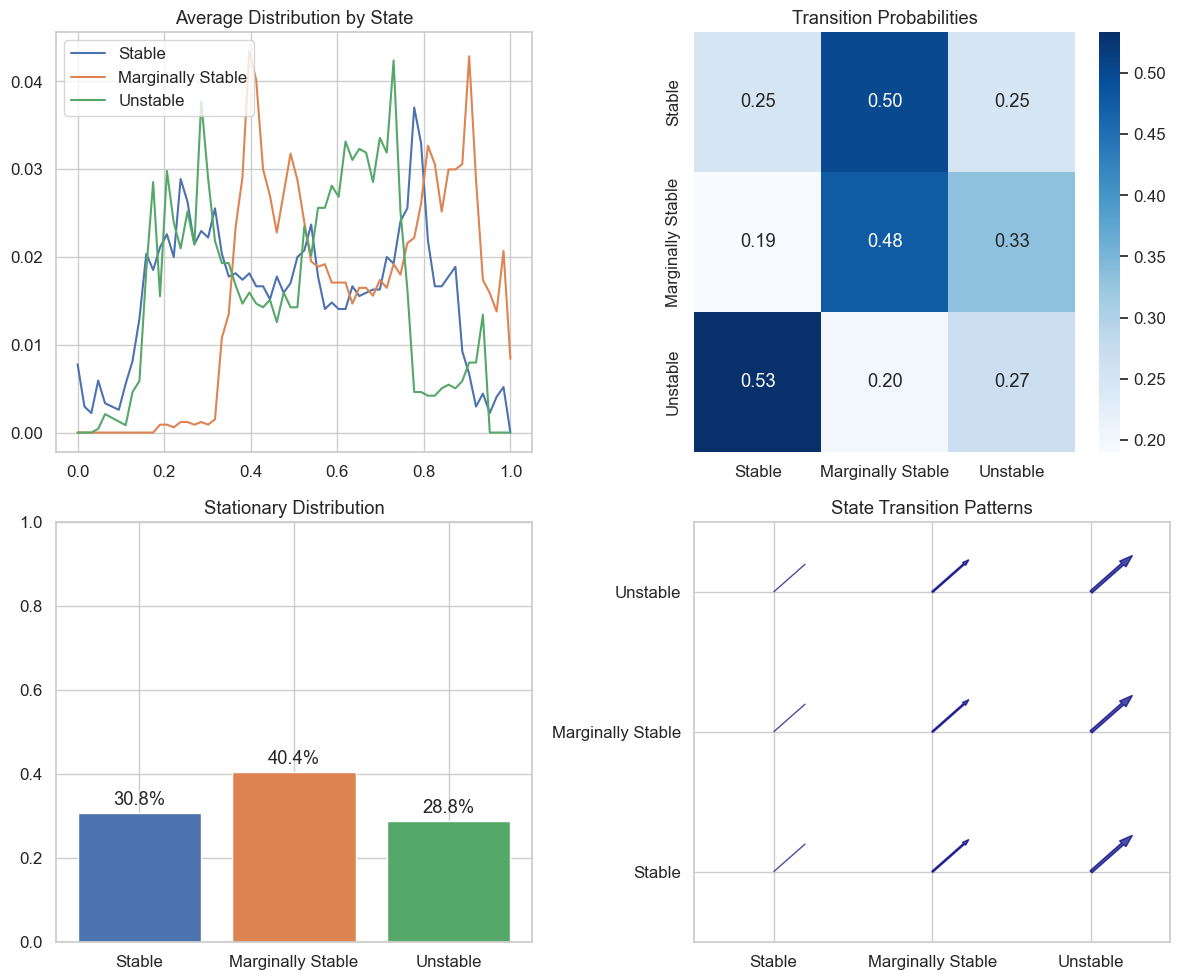

In [33]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "18" / "SWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "18" / "SWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("18_SWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### FWS

Single-stride window = 98 samples (~0.98s)


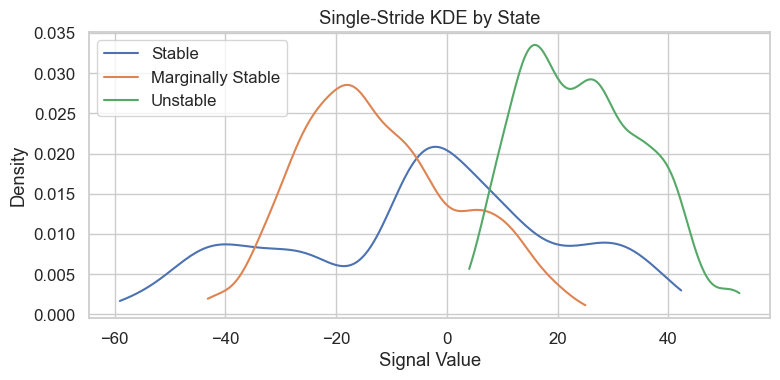

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


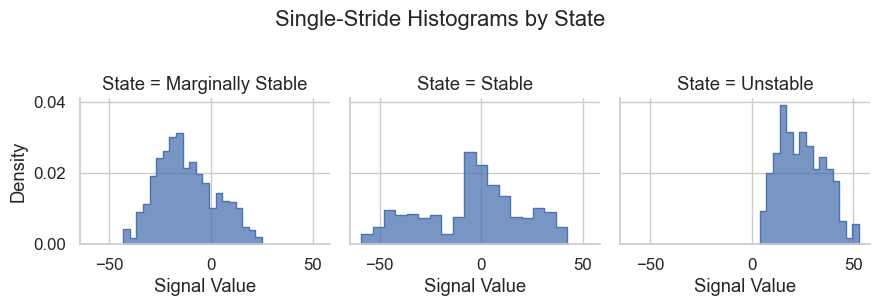

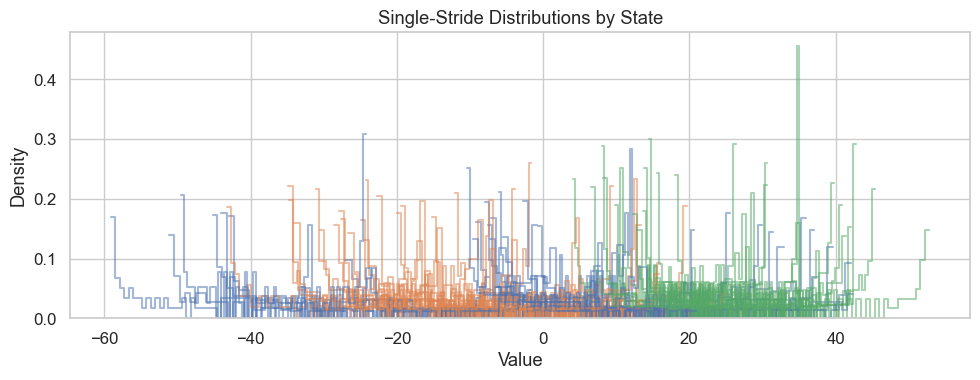

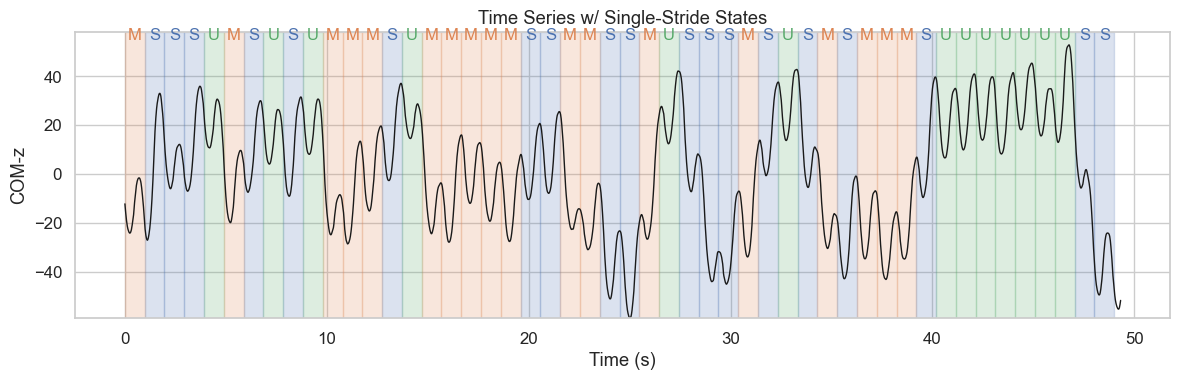

T:
 [[0.389 0.278 0.333]
 [0.444 0.5   0.056]
 [0.308 0.231 0.462]]
Π:
 [0.386 0.341 0.274]
τ:
 [1.636 2.    1.857]
Frac: {'patient_id': '18_SWS', 'frac_state_0': np.float64(0.38), 'frac_state_1': np.float64(0.36), 'frac_state_2': np.float64(0.26)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


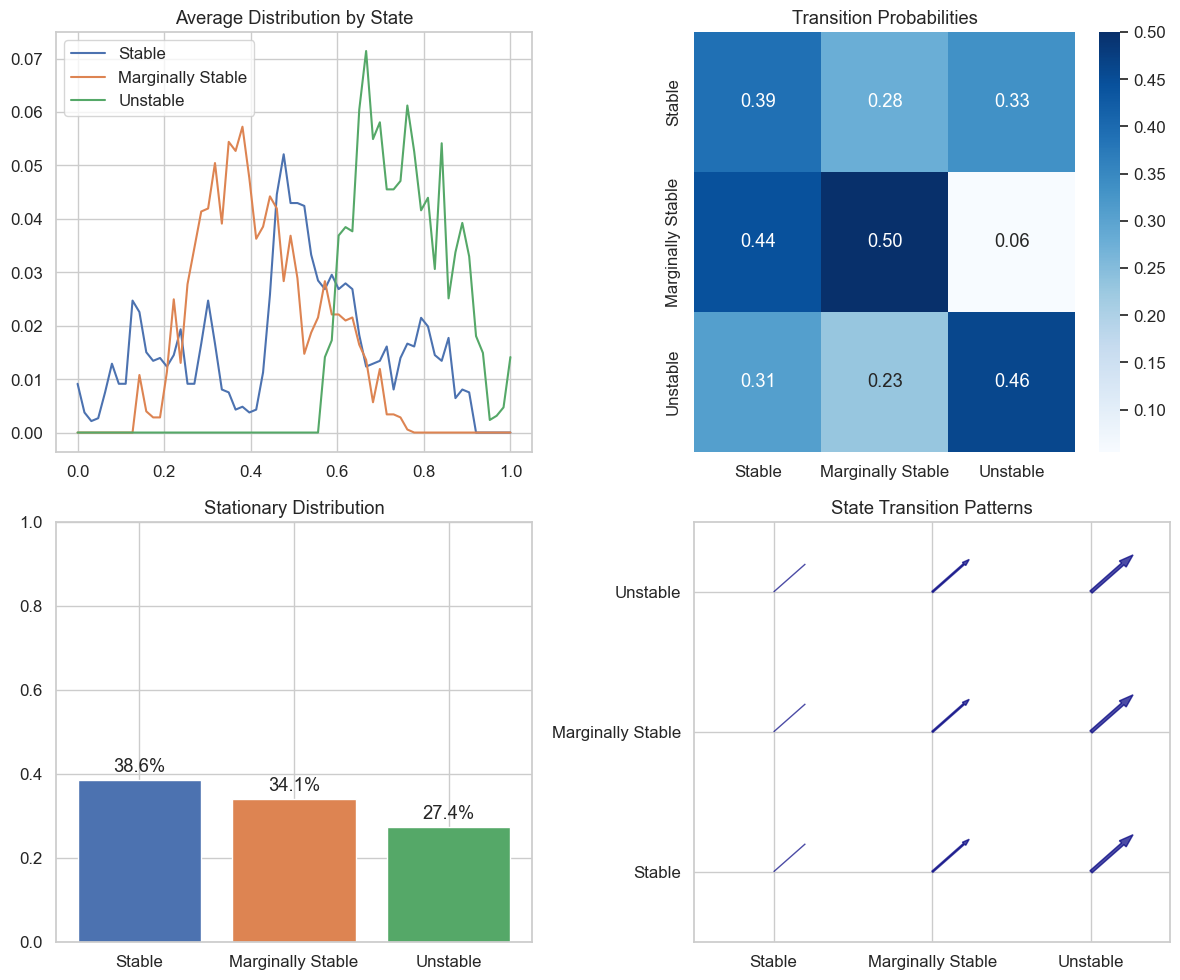

In [34]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "18" / "FWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "18" / "FWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("18_SWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

## Patient 20 - PD

### PWS

Single-stride window = 135 samples (~1.35s)


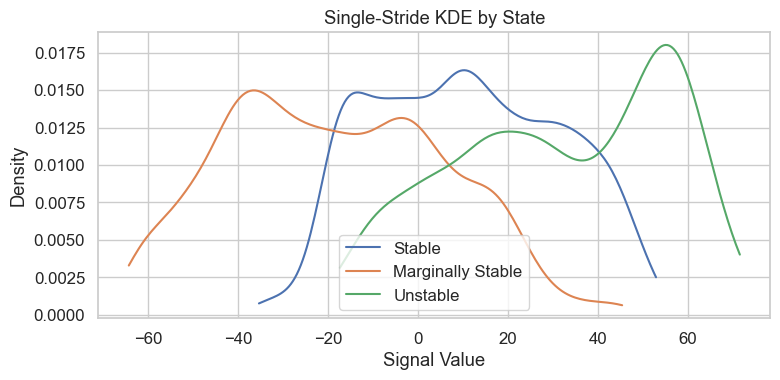

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


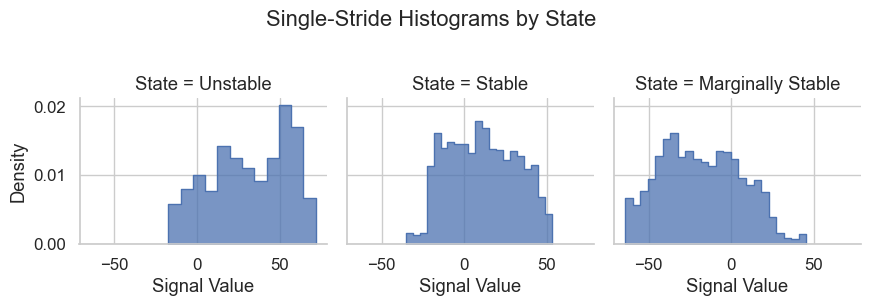

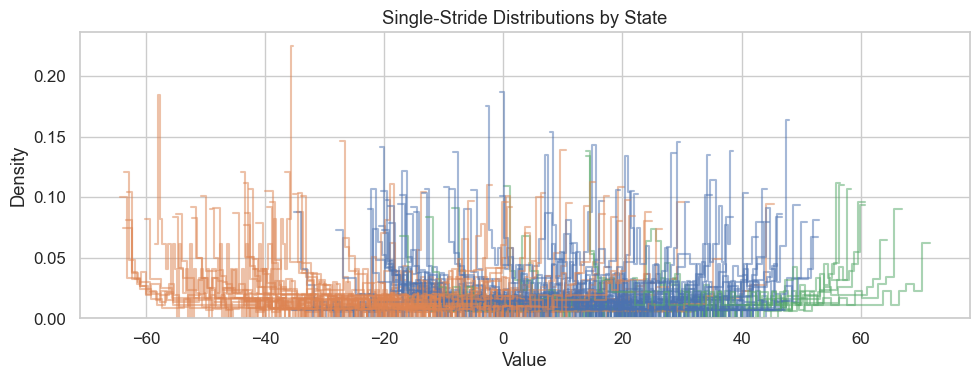

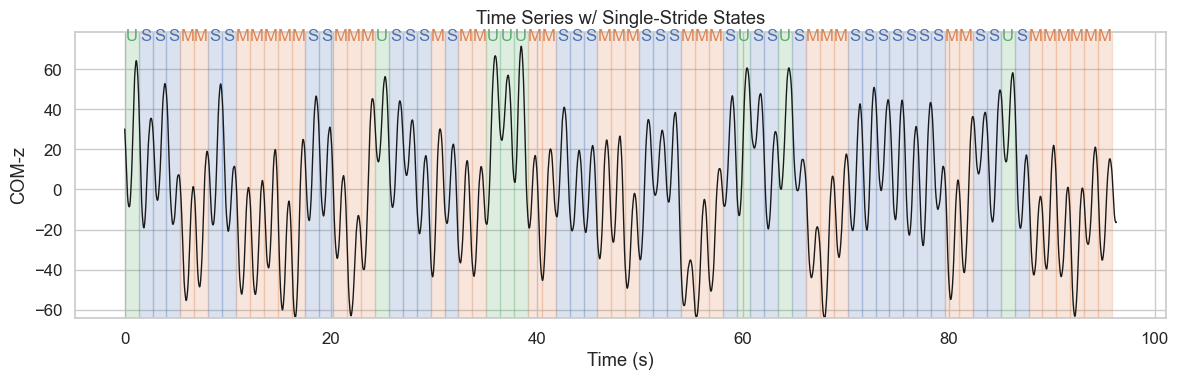

T:
 [[0.581 0.323 0.097]
 [0.258 0.677 0.065]
 [0.625 0.125 0.25 ]]
Π:
 [0.433 0.47  0.096]
τ:
 [2.385 3.1   1.333]
Frac: {'patient_id': '20_PWS', 'frac_state_0': np.float64(0.43661971830985913), 'frac_state_1': np.float64(0.4507042253521127), 'frac_state_2': np.float64(0.11267605633802817)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


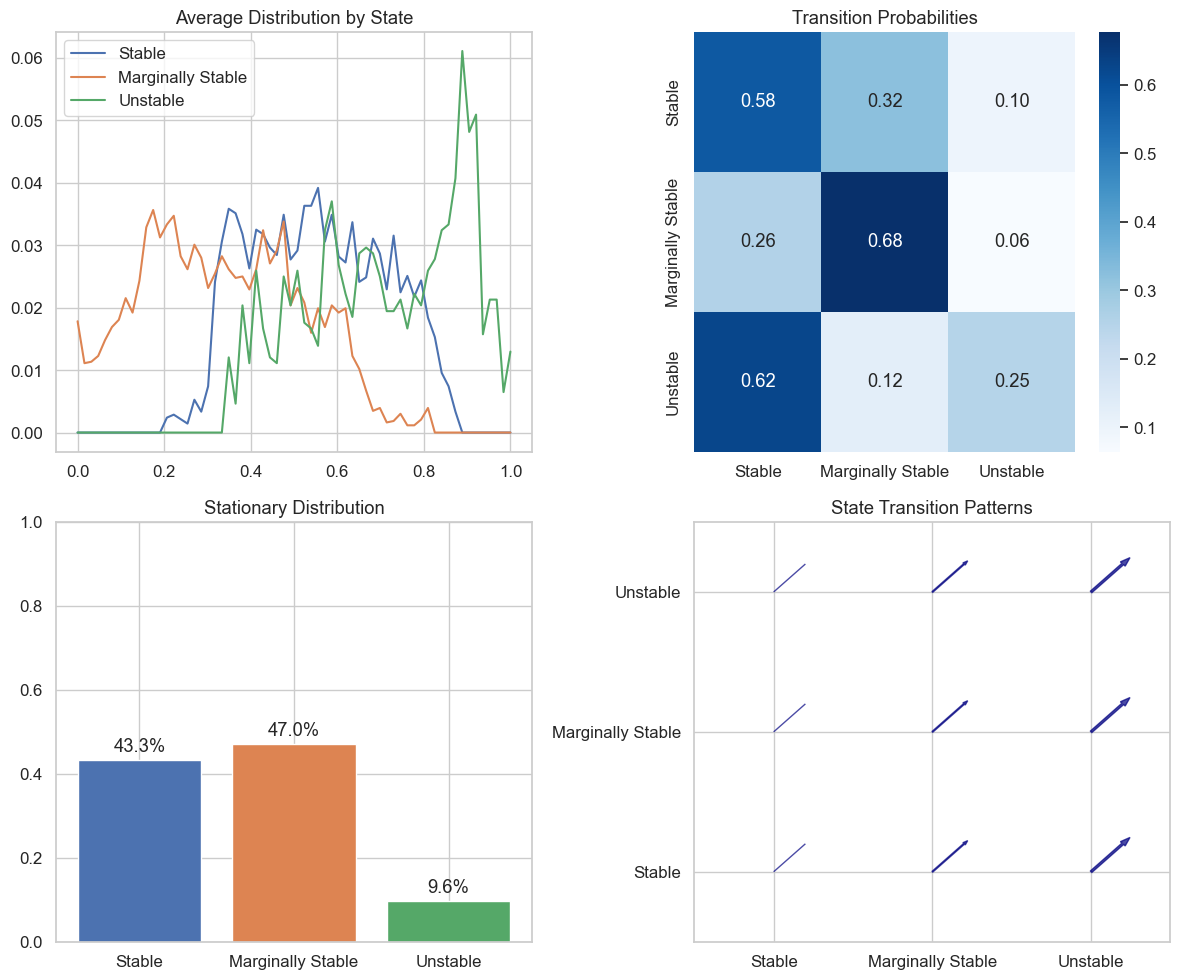

In [35]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "20" / "PWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "20" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("20_PWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

### FWS

Single-stride window = 109 samples (~1.09s)


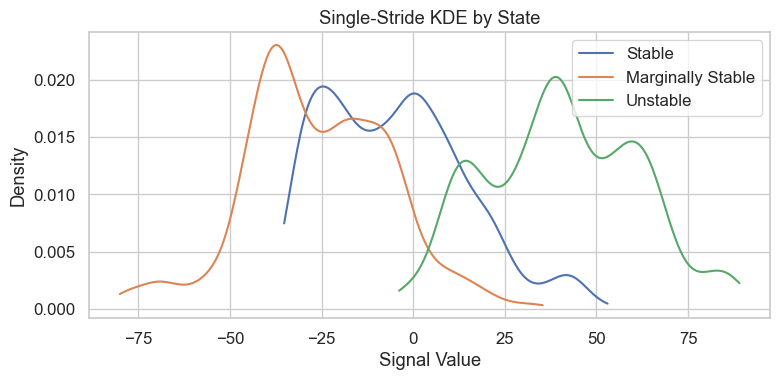

c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


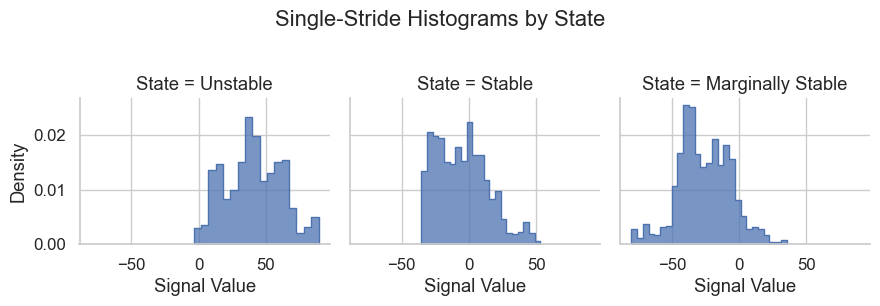

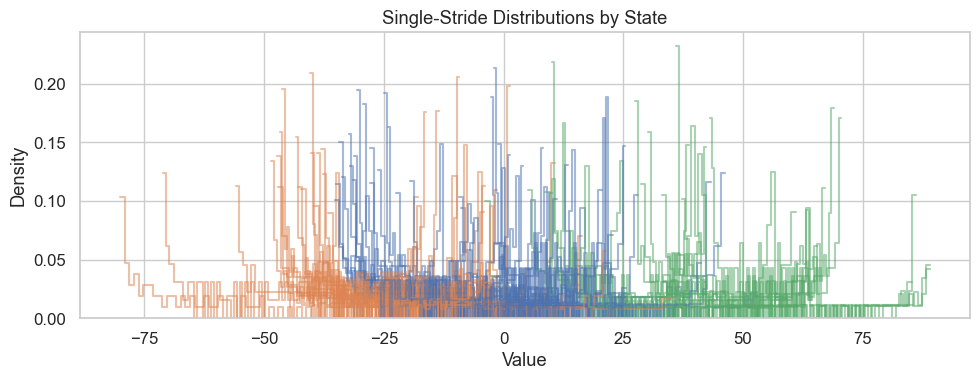

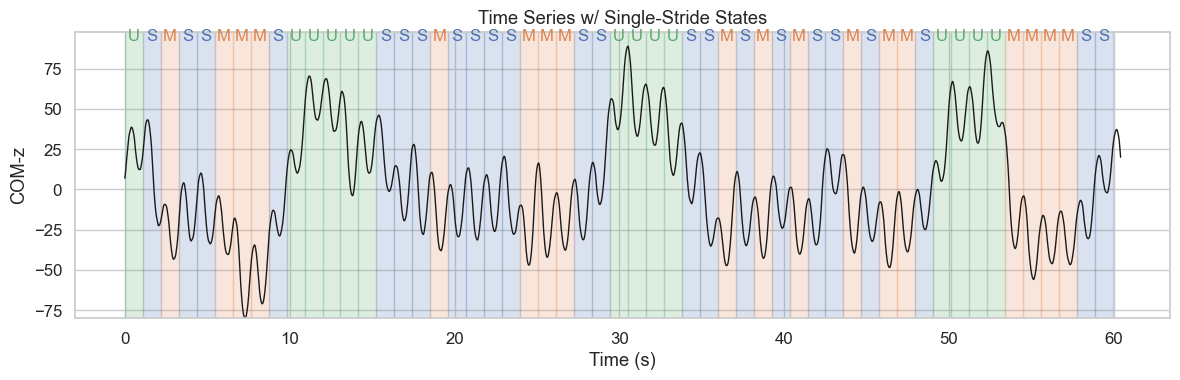

T:
 [[0.455 0.409 0.136]
 [0.556 0.444 0.   ]
 [0.214 0.071 0.714]]
Π:
 [0.44  0.351 0.21 ]
τ:
 [1.833 1.8   3.5  ]
Frac: {'patient_id': '20_FWS', 'frac_state_0': np.float64(0.41818181818181815), 'frac_state_1': np.float64(0.32727272727272727), 'frac_state_2': np.float64(0.2545454545454545)}


C:\Users\Natascha\AppData\Local\Temp\ipykernel_9588\2456384671.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a,b,c = row['from'],row['to'],row[0]


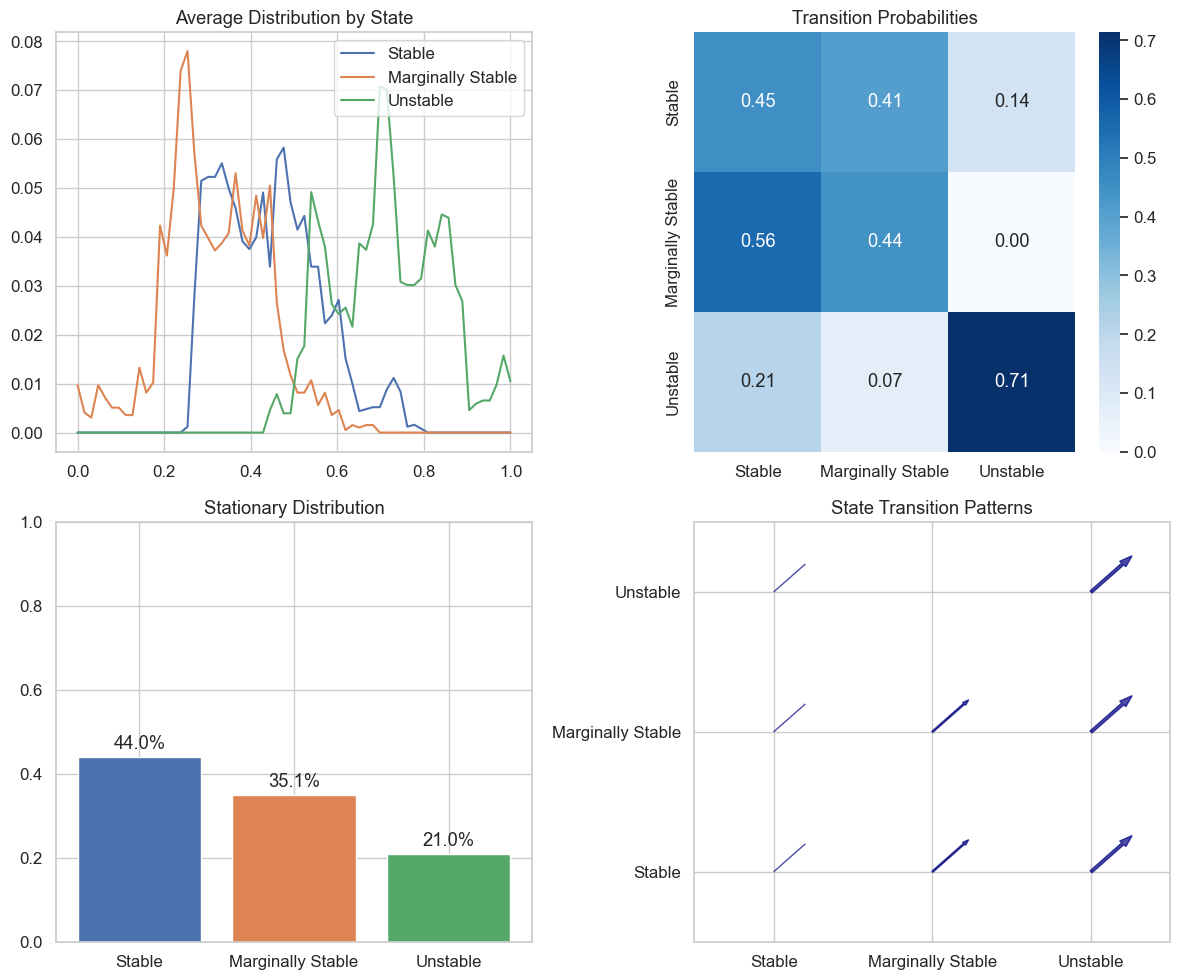

In [38]:

def main():
    cwd         = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "20" / "FWS" / "4"/ "markers.nc"
    events_file  = cwd.parent / ".." / "data" / "CGA" / "20" / "FWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes & single-stride length
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    avg_stride = np.mean(np.diff(strikes))
    win_samps  = int(round(avg_stride * fs))
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) build & run DistributionMSM
    msm = DistributionMSM("20_FWS", n_states=3,
                          window_size=win_samps,
                          window_overlap=0.0,
                          n_bins=64)
    df    = msm.compute_windowed_metrics(ts, fs)
    states= msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    from scipy.stats import gaussian_kde

    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        # gather all samples in windows of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int(df.loc[i,'time'] * fs) + win_samps]
            for i in idxs
        ])
        # compute & plot KDE
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs),
                color=sns.color_palette()[st],
                label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 2) Faceted histograms via Seaborn
    # build a “long” DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st    = int(row.state)
        seg   = ts[int(row.time * fs): int(row.time * fs) + win_samps]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value",
        stat="density", element="step", fill=True,
        palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()
    T     = msm.compute_transition_matrix(states)
    pi    = msm.compute_stationary_distribution()
    tau   = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _,row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        seg   = ts[start:start+win_samps]
        sns.histplot(seg, bins=msm.n_bins,
                     stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State"); plt.xlabel("Value"); plt.ylabel("Density")
    plt.tight_layout(); plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0:"S",1:"M",2:"U"}
    dur     = win_samps/fs
    times   = np.arange(len(ts))/fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _,row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time+dur
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st],
                 ha='center', va='bottom', color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States"); plt.xlabel("Time (s)"); plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout(); plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__=="__main__":
    main()

In [12]:
from pathlib import Path
import xarray as xr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde


def main():
    cwd         = Path.cwd()
    marker_file = cwd.parent / ".." / "data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"markers.nc" 
    events_file = cwd.parent / ".." / "data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre" /"events.nc" 
    fs = 100.0

    # 1) load & preprocess COM-z
    ds  = xr.open_dataset(marker_file)
    da  = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts  = preprocess_signal(raw, fs)
    
    # 2) find strikes
    ev_ds   = xr.open_dataset(events_file)
    ev_da   = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev   = ev_da.to_dataframe().reset_index()
    strikes = np.sort(
        df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values
    )

    # 3) build & run DistributionMSM (stride-based)
    msm = DistributionMSM(
        "04_PWS",
        n_states=3,
        window_size=None,
        window_overlap=0.0,
        n_bins=64
    )

    # compute one histogram per actual stride
    df     = msm.compute_stride_metrics(ts, strikes, fs)
    states = msm.identify_stability_states(df)
        
    # 1) Overlaid kernel‐density estimates (KDEs)
    plt.figure(figsize=(8,4))
    for st, label in msm.state_labels.items():
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(df.loc[i,'time'] * fs) : int((df.loc[i,'time'] + df.loc[i,'duration']) * fs)]
            for i in idxs
        ])
        kde = gaussian_kde(data)
        xs  = np.linspace(data.min(), data.max(), 200)
        plt.plot(xs, kde(xs), color=sns.color_palette()[st], label=label)
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Faceted histograms via Seaborn
    long = []
    for _, row in df.iterrows():
        st  = int(row.state)
        start = int(row.time * fs)
        end   = int((row.time + row.duration) * fs)
        seg   = ts[start:end]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True, palette=sns.color_palette())
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    T       = msm.compute_transition_matrix(states)
    pi      = msm.compute_stationary_distribution()
    tau     = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    # 4) Per-stride histograms colored by state
    colors = sns.color_palette(n_colors=3)
    cmap   = {i: colors[i] for i in range(3)}
    plt.figure(figsize=(10,4))
    for _, row in df.iterrows():
        st    = int(row.state)
        start = int(row.time * fs)
        end   = int((row.time + row.duration) * fs)
        seg   = ts[start:end]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', fill=False,
                     color=cmap[st], alpha=0.5)
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 5) Time series with S/M/U overlay
    letters = {0: "S", 1: "M", 2: "U"}
    times   = np.arange(len(ts)) / fs
    plt.figure(figsize=(12,4))
    plt.plot(times, ts, color='k', lw=1)
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.2)
        plt.text((t0+t1)/2, ts.max()*1.02, letters[st], ha='center', va='bottom',
                 color=cmap[st], fontsize=12)
    plt.title("Time Series w/ Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-z")
    plt.ylim(ts.min(), ts.max()*1.1)
    plt.tight_layout()
    plt.show()

    # 6) print & 2×2 summary
    print("T:\n", np.round(T,3))
    print("Π:\n", np.round(pi,3))
    print("τ:\n", np.round(tau,3))
    print("Frac:", summary)
    msm.visualize_patient_analysis()


if __name__ == "__main__":
    main()


c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation\venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


ValueError: Input X contains NaN.
GaussianMixture does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values